<a href="https://colab.research.google.com/github/Rodrigo-Weber-dos-Santos/Rodrigo-Weber-dos-Santos/blob/main/encounter_memory_kernels_reproducibility_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encounter-Memory Kernels for Diffusion-Controlled Chemical Kinetics

Clean reproducibility notebook for the manuscript figures.



In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Consistent, simple plotting defaults. No custom color palette is enforced;
# matplotlib defaults are used for portability.
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
})

print(f"Figures will be saved in: {FIG_DIR.resolve()}")


Figures will be saved in: /content/figures


## 1. Photoinduced electron transfer: synthetic DET-inspired target curves

In [2]:
# ============================================================
# BLOCK 1 — SYNTHETIC DET-INSPIRED DATA FOR A TrCA/DMA-LIKE CASE
#
# Idea:
#   1) Build a positive spatial ET kernel w(r) of Marcus type
#   2) Solve a standard radial diffusion-reaction PDE for p(r,t)
#   3) Compute k(t) = 4 pi ∫ w(r) p(r,t) r^2 dr
#   4) Generate synthetic fluorescence/survival curves
#        S(t,c) = exp[-t/tau0 - c ∫_0^t k(u) du]
#
# Notes:
#   - This is DET-inspired and uses the same physical ingredients
#     highlighted in the paper.
#   - It is not an exact recreation of the SI implementation.
#   - Units:
#       time      = ns
#       distance  = nm
#       energy    = eV
#       conc      = M
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ----------------------------
# utilities
# ----------------------------

def cumulative_trapezoid_manual(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y)
    out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(x))
    return out

# ----------------------------
# TrCA/DMA-like photophysical constants
# ----------------------------

tau0_ns = 18.4           # TrCA lifetime in MeCN from the paper
T_K = 293.15
kBT_eV = 8.617333262e-5 * T_K
hbar_eV_ps = 6.582119569e-4
coulomb_eV_nm = 1.43996448   # e^2 / (4*pi*eps0) in eV*nm

# solvent values used in the paper for MeCN
eps_s = 36.0
n_refr = 1.344

# ----------------------------
# radial diffusion-reaction model setup
# ----------------------------

s_nm = 0.65              # contact distance (illustrative, molecule-size scale)
rmax_nm = 4.0
nr = 260
r = np.linspace(s_nm, rmax_nm, nr)
dr = r[1] - r[0]

D_nm2_ns = 2.0           # mutual diffusion coefficient, illustrative but realistic scale

# time grid for synthetic curves
tmax_ns = 0.50
nt = 1001
t_ns = np.linspace(0.0, tmax_ns, nt)

# concentrations to mimic Figure-2/3-style series
concentrations_M = np.array([0.002, 0.005, 0.010, 0.015, 0.020])

# conversion: 1 M = 0.602214... molecules / nm^3
M_to_numdens_nm3 = 0.602214076

# ----------------------------
# Marcus-like positive spatial kernel w(r)
# ----------------------------
#
# The paper uses a modified Marcus ET model.
# Here we keep the same structure:
#   w(r) ~ |V(r)|^2 / sqrt(lambda(r)) * exp[-(DG(r)+lambda(r))^2/(4 lambda(r) kBT)]
#
# with:
#   V(r) = V0 exp[-(r-s)/L]
#   DG(r) = DG_inf - e^2/(4*pi*eps0*eps_s*r)
#   lambda(r) = lambda_inner + lambda_solv(r)
#
# Parameters below are illustrative and chosen to generate
# clearly nonexponential TrCA/DMA-like synthetic kinetics.

V0_eV = 0.060            # electronic coupling at contact
L_nm = 0.12              # coupling decay length
DG_inf_eV = -0.95        # long-range driving force
lambda_inner_eV = 0.18
lambda_s_contact_eV = 0.45

def V_of_r(r_nm):
    return V0_eV * np.exp(-(r_nm - s_nm) / L_nm)

def DG_of_r(r_nm):
    # Weller-like Coulombic distance dependence
    return DG_inf_eV - coulomb_eV_nm / (eps_s * np.maximum(r_nm, s_nm))

def lambda_s_of_r(r_nm):
    # simple decreasing solvent reorganization profile, paper-inspired
    # keeps lambda(r) positive and larger near contact
    return lambda_s_contact_eV * (2.0 - s_nm / np.maximum(r_nm, s_nm))

def lambda_of_r(r_nm):
    lam = lambda_inner_eV + lambda_s_of_r(r_nm)
    return np.maximum(lam, 1e-6)

def w_of_r_ns_inv(r_nm):
    V = V_of_r(r_nm)
    DG = DG_of_r(r_nm)
    lam = lambda_of_r(r_nm)

    FC = np.exp(-((DG + lam) ** 2) / (4.0 * lam * kBT_eV)) / np.sqrt(4.0 * np.pi * lam * kBT_eV)

    # Marcus nonadiabatic prefactor: 2pi/hbar * |V|^2 * FC
    w_ps_inv = (2.0 * np.pi / hbar_eV_ps) * (V ** 2) * FC
    w_ns_inv = 1000.0 * w_ps_inv
    return np.maximum(w_ns_inv, 0.0)

w_r = w_of_r_ns_inv(r)

print(f"Contact ET probability w(s) ~ {w_r[0]:.3e} ns^-1")
print(f"Far-field ET probability w(rmax) ~ {w_r[-1]:.3e} ns^-1")

# ----------------------------
# solve radial diffusion-reaction PDE
#
#   ∂p/∂t = D [ p_rr + (2/r) p_r ] - w(r) p
#
# IC: p(r,0) = 1
# BC at r=s: reflecting  (dp/dr = 0)
# BC at r=rmax: bulk reservoir p = 1
#
# This yields a concentration-independent k(t), as in the paper.
# ----------------------------

def rhs_pair_pde(t, y):
    # y contains p at nodes 0..nr-2 ; last node fixed to bulk value 1
    p = np.empty(nr, dtype=float)
    p[:-1] = y
    p[-1] = 1.0

    dy = np.zeros(nr - 1, dtype=float)

    # i = 0 : reflecting boundary at contact
    p_rr_0 = 2.0 * (p[1] - p[0]) / dr**2
    dy[0] = D_nm2_ns * p_rr_0 - w_r[0] * p[0]

    # interior i = 1..nr-2
    rr = r[1:-1]
    p_rr = (p[2:] - 2.0 * p[1:-1] + p[:-2]) / dr**2
    p_r = (p[2:] - p[:-2]) / (2.0 * dr)

    dy[1:] = D_nm2_ns * (p_rr + 2.0 * p_r / rr) - w_r[1:-1] * p[1:-1]
    return dy

y0 = np.ones(nr - 1, dtype=float)

sol = solve_ivp(
    rhs_pair_pde,
    (t_ns[0], t_ns[-1]),
    y0,
    t_eval=t_ns,
    method="BDF",
    rtol=1e-7,
    atol=1e-9,
)

if not sol.success:
    raise RuntimeError(sol.message)

p_rt = np.empty((nr, len(t_ns)), dtype=float)
p_rt[:-1, :] = sol.y
p_rt[-1, :] = 1.0

# k_geom has units nm^3 / ns
k_geom_nm3_ns = 4.0 * np.pi * np.trapz((w_r[:, None] * p_rt) * (r[:, None] ** 2), r, axis=0)

# convert to M^-1 ns^-1 so that c[M] * k(t) gives ns^-1
k_M_ns_inv = M_to_numdens_nm3 * k_geom_nm3_ns

print(f"k(0) ~ {k_M_ns_inv[0]:.3e} M^-1 ns^-1")
print(f"k(tmax) ~ {k_M_ns_inv[-1]:.3e} M^-1 ns^-1")

# ----------------------------
# build synthetic survival curves from the paper's fluorescence law
#   S(t,c) = exp[-t/tau0 - c ∫ k(u) du]
# ----------------------------

K_int = cumulative_trapezoid_manual(k_M_ns_inv, t_ns)

synthetic_clean = {}
synthetic_noisy = {}

rng = np.random.default_rng(1234)
noise_level = 0.002  # 0.2%

for cM in concentrations_M:
    S = np.exp(-t_ns / tau0_ns - cM * K_int)
    synthetic_clean[cM] = S

    noisy = np.clip(S * (1.0 + noise_level * rng.standard_normal(len(S))), 1e-12, 1.0)
    synthetic_noisy[cM] = noisy


print("ET synthetic targets ready:")
print(f"  time points = {len(t_ns)}")
print(f"  concentrations_M = {concentrations_M}")
print("  variables: t_ns, concentrations_M, tau0_ns, synthetic_clean, k_M_ns_inv")


Contact ET probability w(s) ~ 7.807e+03 ns^-1
Far-field ET probability w(rmax) ~ 3.360e-20 ns^-1
k(0) ~ 3.431e+03 M^-1 ns^-1
k(tmax) ~ 2.322e+01 M^-1 ns^-1
ET synthetic targets ready:
  time points = 1001
  concentrations_M = [0.002 0.005 0.01  0.015 0.02 ]
  variables: t_ns, concentrations_M, tau0_ns, synthetic_clean, k_M_ns_inv


/tmp/ipykernel_11737/2359652324.py:181: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  k_geom_nm3_ns = 4.0 * np.pi * np.trapz((w_r[:, None] * p_rt) * (r[:, None] ** 2), r, axis=0)


## 2. Figure 1: ET gamma, exponential, and delay memory fits

Fit grid: 334 points, dt = 0.0015 ns
Concentrations: [0.002, 0.005, 0.01, 0.015, 0.02]

FITTING MODEL: gamma
start 0: cost = 0.001841
start 1: cost = 0.001841
start 2: cost = 0.001841

FITTING MODEL: exponential
start 0: cost = 0.031322
start 1: cost = 0.031322
start 2: cost = 0.031322

FITTING MODEL: delay
start 0: cost = 0.055815
start 1: cost = 0.060352
start 2: cost = 0.071041

SUMMARY
      model     cost  mean_rel_err  max_rel_err   tau0_ns          Q0     A_loc      k_q    tau_q  tau_d  delta_cost
      gamma 0.001841      0.001004     0.001639 16.831604 1160.582732 20.765495 0.031619 0.003134    NaN    0.000000
exponential 0.031322      0.003477     0.006632 17.574622  550.572469 25.167301 1.000000 0.006542    NaN    0.029481
      delay 0.055815      0.004272     0.007943 18.583415  430.036917 28.704015      NaN      NaN  0.009    0.053973


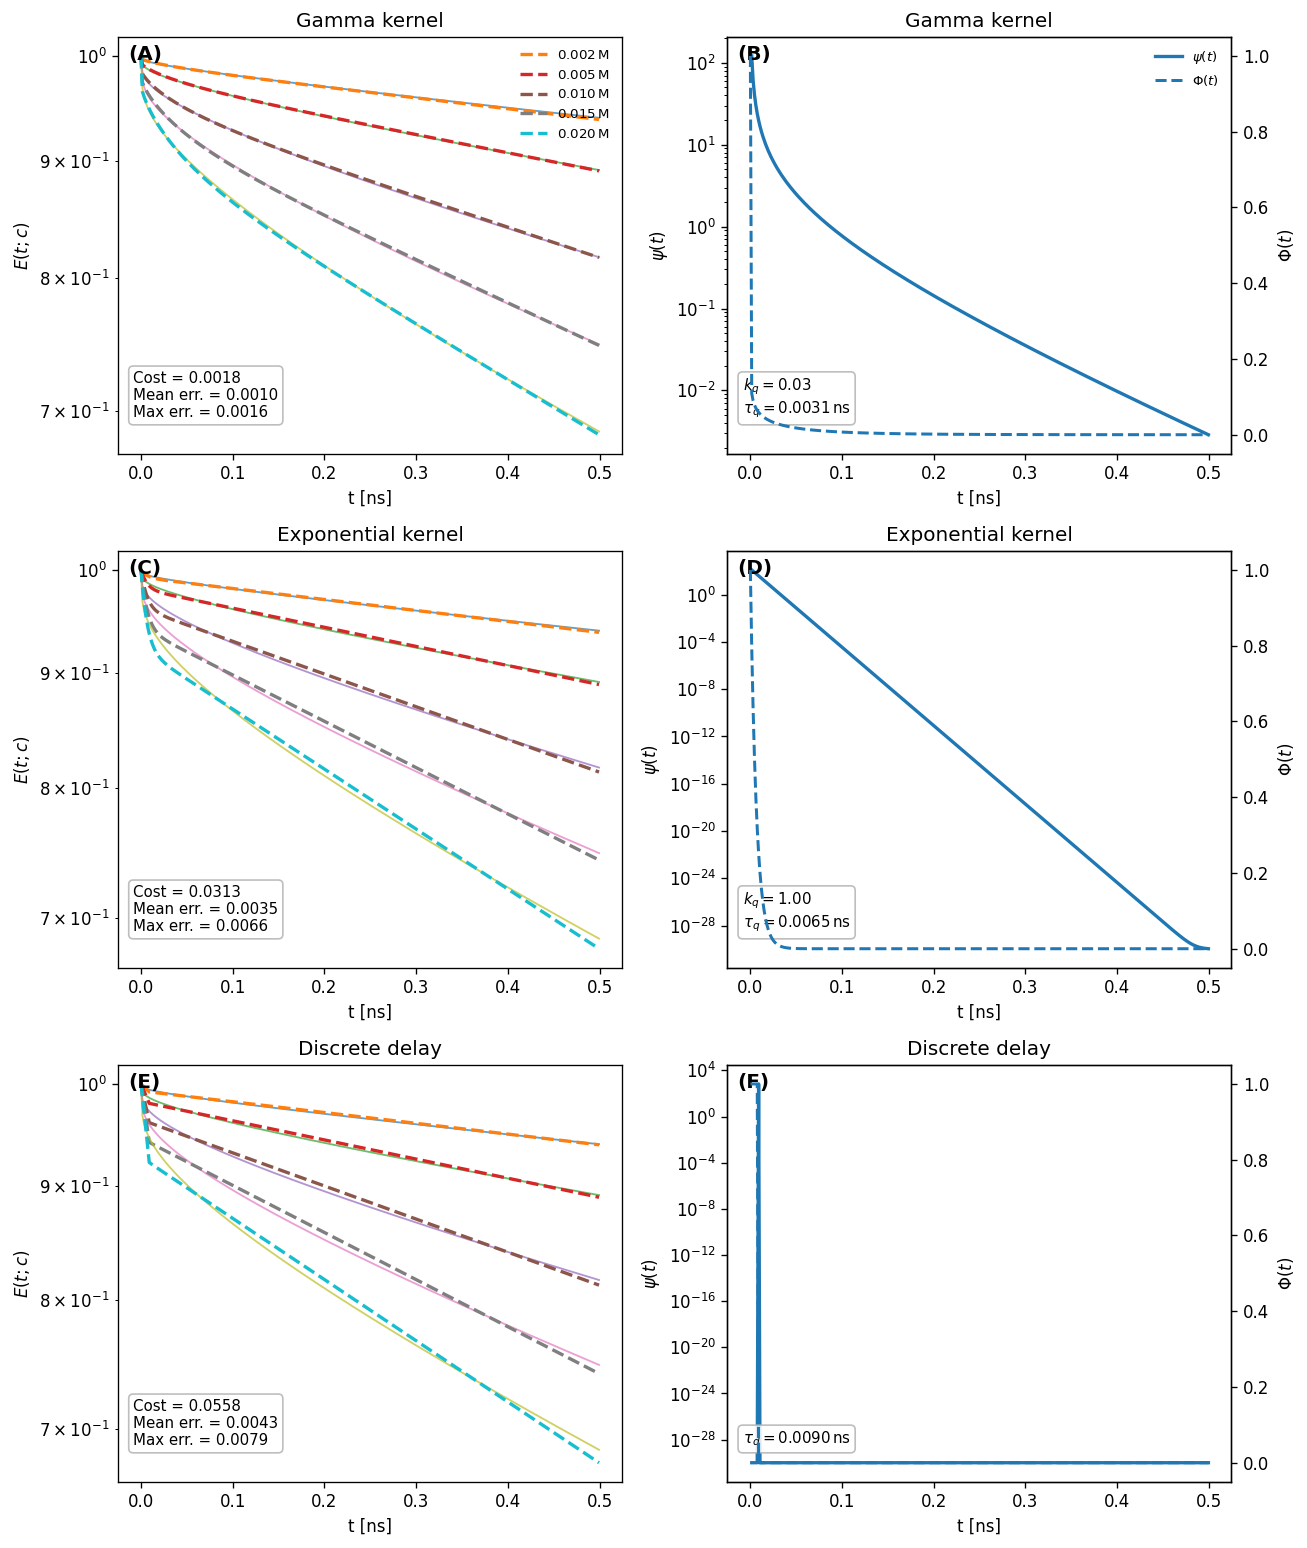


Saved:
  figures/figure1_et_three_models_comparison.png
  figures/figure1_et_three_models_comparison.pdf


In [3]:
# ============================================================
# FIT THREE MODELS TO SYNTHETIC ET DATA
#
# Models:
#
# 1) Gamma kernel
#    dE/dt = -E/tau0 - c [ Q0 Phi(t) + A_loc * ∫_0^t psi(t-s) E(s) ds ]
#
# 2) Exponential kernel (exact)
#    same as above, with psi(t) = (1/tau_q) exp(-t/tau_q)
#    i.e. gamma kernel with k_q = 1
#
# 3) Discrete-delay kernel (exact)
#    psi(t) = delta(t - tau_d),   Phi(t) = H(tau_d - t)
#    so
#    dE/dt = -E/tau0 - c [ Q0 H(tau_d - t) + A_loc E(t - tau_d) H(t - tau_d) ]
#
# Expected variables already in memory:
#   t_ns
#   concentrations_M
#   synthetic_clean or synthetic_noisy
#
# Outputs:
#   - comparison table
#   - 3x2 comparison figure
#   - saved files:
#       et_three_models_comparison.png
#       et_three_models_comparison.pdf
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.special import gammaln, gammaincc

# ------------------------------------------------------------
# Basic checks / choose target data
# ------------------------------------------------------------

required = ["t_ns", "concentrations_M"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError("Missing required variables: " + ", ".join(missing))

if "synthetic_clean" in globals():
    target_data = synthetic_clean
elif "synthetic_noisy" in globals():
    target_data = synthetic_noisy
else:
    raise RuntimeError("Need synthetic_clean or synthetic_noisy in memory.")

fit_stride = 3
t_fit = np.asarray(t_ns[::fit_stride], dtype=float).copy()
concentrations_M = [float(c) for c in concentrations_M]
targets = {
    cM: np.asarray(target_data[cM][::fit_stride], dtype=float).copy()
    for cM in concentrations_M
}

if len(t_fit) < 5:
    raise RuntimeError("t_fit too short. Check t_ns / fit_stride.")

dt = float(t_fit[1] - t_fit[0])
eps = 1e-14

print(f"Fit grid: {len(t_fit)} points, dt = {dt:.6g} ns")
print("Concentrations:", concentrations_M)

# ------------------------------------------------------------
# Weights used in the fit
# ------------------------------------------------------------

weights_t = 1.0 + 6.0 * np.exp(-t_fit / 0.008) + 0.2 * (t_fit / max(t_fit.max(), 1e-12))

# ------------------------------------------------------------
# Helpers for gamma kernel
# ------------------------------------------------------------

def build_gamma_pdf_on_grid(k_shape, theta_k, t_grid):
    if k_shape <= 0 or theta_k <= 0:
        return None

    t = np.asarray(t_grid, dtype=float).copy()
    if len(t) < 2:
        return None

    tt = t.copy()
    tt[0] = max(0.5 * (t[1] - t[0]), 1e-12)
    tt[1:] = np.clip(tt[1:], 1e-300, None)

    with np.errstate(over="ignore", under="ignore", invalid="ignore"):
        log_pdf = (
            (k_shape - 1.0) * np.log(tt)
            - tt / theta_k
            - gammaln(k_shape)
            - k_shape * np.log(theta_k)
        )
        pdf = np.exp(log_pdf)

    if np.any(~np.isfinite(pdf)) or np.any(pdf < 0):
        return None

    Z = np.trapezoid(pdf, t)
    if (not np.isfinite(Z)) or Z <= 0:
        return None

    return pdf / Z

def build_gamma_psi_phi(k_q, tau_q, t_grid):
    if k_q <= 0 or tau_q <= 0:
        return None, None

    theta_q = tau_q / k_q
    psi_q = build_gamma_pdf_on_grid(k_q, theta_q, t_grid)
    if psi_q is None:
        return None, None

    t = np.asarray(t_grid, dtype=float)
    Phi_q = gammaincc(k_q, np.clip(t / theta_q, 0.0, None))

    if np.any(~np.isfinite(Phi_q)) or np.any(Phi_q < 0) or np.any(Phi_q > 1.000001):
        return None, None

    return psi_q, Phi_q

# ------------------------------------------------------------
# Delay helper
# ------------------------------------------------------------

def delayed_value_zero_prehistory(t_query, t_hist, y_hist):
    """
    Returns y(t_query) using linear interpolation on known history.
    Uses zero prehistory for t_query < 0.
    """
    if t_query < 0:
        return 0.0
    if t_query <= t_hist[0]:
        return float(y_hist[0])
    if t_query >= t_hist[-1]:
        return float(y_hist[-1])
    return float(np.interp(t_query, t_hist, y_hist))

# ------------------------------------------------------------
# Model simulators
# ------------------------------------------------------------

def simulate_gamma(theta, t_grid, concs):
    # theta = [tau0_ns, Q0, A_loc, k_q, tau_q]
    tau0_ns, Q0, A_loc, k_q, tau_q = theta

    if tau0_ns <= 0 or Q0 < 0 or A_loc < 0 or k_q <= 0 or tau_q <= 0:
        return None

    psi_q, Phi_q = build_gamma_psi_phi(k_q, tau_q, t_grid)
    if psi_q is None or Phi_q is None:
        return None

    n = len(t_grid)
    dt_local = float(t_grid[1] - t_grid[0])
    curves = {}

    for cM in concs:
        E = np.zeros(n, dtype=float)
        q_ET = np.zeros(n, dtype=float)
        E[0] = 1.0

        for i in range(1, n):
            conv_prev = dt_local * np.dot(psi_q[:i], E[i-1::-1])
            q_prev = cM * (Q0 * Phi_q[i-1] + A_loc * conv_prev)
            q_ET[i-1] = q_prev

            dE = -E[i-1] / tau0_ns - q_prev
            E[i] = E[i-1] + dt_local * dE
            E[i] = np.clip(E[i], 1e-15, 1.0)

        conv_last = dt_local * np.dot(psi_q[:n], E[n-1::-1])
        q_ET[-1] = cM * (Q0 * Phi_q[-1] + A_loc * conv_last)

        curves[cM] = {"E": E, "q_ET": q_ET}

    return {
        "pars": {
            "tau0_ns": tau0_ns,
            "Q0": Q0,
            "A_loc": A_loc,
            "k_q": k_q,
            "tau_q": tau_q,
        },
        "curves": curves,
        "psi": psi_q,
        "Phi": Phi_q,
    }

def simulate_exponential(theta, t_grid, concs):
    # theta = [tau0_ns, Q0, A_loc, tau_q]
    tau0_ns, Q0, A_loc, tau_q = theta
    return simulate_gamma([tau0_ns, Q0, A_loc, 1.0, tau_q], t_grid, concs)

def simulate_discrete_delay(theta, t_grid, concs):
    # theta = [tau0_ns, Q0, A_loc, tau_d]
    tau0_ns, Q0, A_loc, tau_d = theta

    if tau0_ns <= 0 or Q0 < 0 or A_loc < 0 or tau_d < 0:
        return None

    n = len(t_grid)
    dt_local = float(t_grid[1] - t_grid[0])
    curves = {}

    for cM in concs:
        E = np.zeros(n, dtype=float)
        q_ET = np.zeros(n, dtype=float)
        E[0] = 1.0

        for i in range(1, n):
            t_prev = t_grid[i-1]

            # Static contribution from initially reactive pairs
            H_static = 1.0 if t_prev <= tau_d else 0.0

            # Dynamic delayed contribution
            if t_prev >= tau_d:
                E_delay = delayed_value_zero_prehistory(t_prev - tau_d, t_grid[:i], E[:i])
            else:
                E_delay = 0.0

            q_prev = cM * (Q0 * H_static + A_loc * E_delay)
            q_ET[i-1] = q_prev

            dE = -E[i-1] / tau0_ns - q_prev
            E[i] = E[i-1] + dt_local * dE
            E[i] = np.clip(E[i], 1e-15, 1.0)

        t_last = t_grid[-1]
        H_static = 1.0 if t_last <= tau_d else 0.0
        if t_last >= tau_d:
            E_delay = delayed_value_zero_prehistory(t_last - tau_d, t_grid, E)
        else:
            E_delay = 0.0
        q_ET[-1] = cM * (Q0 * H_static + A_loc * E_delay)

        curves[cM] = {"E": E, "q_ET": q_ET}

    # Exact delay objects for visualization:
    # psi = delta(t - tau_d), Phi = H(tau_d - t)
    # Since delta cannot be plotted directly, we show a one-bin spike with area ~ 1.
    psi_display = np.zeros_like(t_grid, dtype=float)
    if tau_d <= t_grid[-1]:
        idx = int(np.argmin(np.abs(t_grid - tau_d)))
        psi_display[idx] = 1.0 / max(dt_local, 1e-15)

    Phi_display = (t_grid <= tau_d).astype(float)

    return {
        "pars": {
            "tau0_ns": tau0_ns,
            "Q0": Q0,
            "A_loc": A_loc,
            "tau_d": tau_d,
        },
        "curves": curves,
        "psi": psi_display,
        "Phi": Phi_display,
    }

# ------------------------------------------------------------
# Residual
# ------------------------------------------------------------

def residual_model(theta, model_name):
    if model_name == "gamma":
        sim = simulate_gamma(theta, t_fit, concentrations_M)
    elif model_name == "exponential":
        sim = simulate_exponential(theta, t_fit, concentrations_M)
    elif model_name == "delay":
        sim = simulate_discrete_delay(theta, t_fit, concentrations_M)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    if sim is None:
        return 1e6 * np.ones(len(t_fit) * len(concentrations_M), dtype=float)

    residuals = []
    for cM in concentrations_M:
        E_pred = sim["curves"][cM]["E"]
        E_tgt = targets[cM]

        rr = weights_t * (
            np.log(np.clip(E_pred, eps, 1.0))
            - np.log(np.clip(E_tgt, eps, 1.0))
        )

        if np.any(~np.isfinite(rr)):
            return 1e6 * np.ones(len(t_fit) * len(concentrations_M), dtype=float)

        residuals.append(rr)

    return np.concatenate(residuals)

# ------------------------------------------------------------
# Fit configurations
# ------------------------------------------------------------

fit_configs = {
    "gamma": {
        # [tau0_ns, Q0, A_loc, k_q, tau_q]
        "bounds": (
            [0.05, 1e-8, 1e-8, 0.01, 1e-5],
            [100.0, 5e3, 500.0, 20.0, 0.05],
        ),
        "starts": [
            [19.4, 1168.0, 21.1, 0.03, 0.0034],
            [20.0,  800.0, 20.0, 0.10, 0.0050],
            [20.0, 1500.0, 30.0, 1.00, 0.0080],
        ],
    },
    "exponential": {
        # [tau0_ns, Q0, A_loc, tau_q]
        "bounds": (
            [0.05, 1e-8, 1e-8, 1e-5],
            [100.0, 5e3, 500.0, 0.05],
        ),
        "starts": [
            [18.5, 550.0, 25.3, 0.0067],
            [20.0, 900.0, 20.0, 0.0040],
            [20.0, 200.0, 40.0, 0.0100],
        ],
    },
    "delay": {
        # [tau0_ns, Q0, A_loc, tau_d]
        "bounds": (
            [0.05, 1e-8, 1e-8, 0.0],
            [100.0, 5e3, 500.0, 0.05],
        ),
        "starts": [
            [18.6, 430.0, 28.6, 0.0084],
            [20.0, 900.0, 20.0, 0.0040],
            [20.0, 200.0, 40.0, 0.0100],
        ],
    },
}

# ------------------------------------------------------------
# Fit routine
# ------------------------------------------------------------

def fit_model(model_name):
    cfg = fit_configs[model_name]
    lb = np.array(cfg["bounds"][0], dtype=float)
    ub = np.array(cfg["bounds"][1], dtype=float)

    best_sol = None
    best_cost = np.inf

    print("\n" + "=" * 70)
    print(f"FITTING MODEL: {model_name}")
    print("=" * 70)

    for j, x0 in enumerate(cfg["starts"]):
        x0 = np.clip(np.array(x0, dtype=float), lb + 1e-12, ub - 1e-12)

        try:
            sol = least_squares(
                residual_model,
                x0,
                bounds=(lb, ub),
                args=(model_name,),
                method="trf",
                max_nfev=2500,
                xtol=1e-8,
                ftol=1e-8,
                gtol=1e-8,
                verbose=0,
            )
            print(f"start {j}: cost = {sol.cost:.6f}")

            if np.isfinite(sol.cost) and sol.cost < best_cost:
                best_sol = sol
                best_cost = sol.cost

        except Exception as err:
            print(f"start {j} failed: {err}")

    if best_sol is None:
        raise RuntimeError(f"All starts failed for model {model_name}.")

    if model_name == "gamma":
        best_sim = simulate_gamma(best_sol.x, t_fit, concentrations_M)
    elif model_name == "exponential":
        best_sim = simulate_exponential(best_sol.x, t_fit, concentrations_M)
    else:
        best_sim = simulate_discrete_delay(best_sol.x, t_fit, concentrations_M)

    rows = []
    for cM in concentrations_M:
        E_pred = best_sim["curves"][cM]["E"]
        E_tgt = targets[cM]
        rel_err = np.linalg.norm(E_pred - E_tgt) / max(np.linalg.norm(E_tgt), 1e-15)
        rows.append(rel_err)

    out = {
        "model": model_name,
        "sol": best_sol,
        "sim": best_sim,
        "cost": float(best_sol.cost),
        "mean_rel_err": float(np.mean(rows)),
        "max_rel_err": float(np.max(rows)),
    }
    return out

# ------------------------------------------------------------
# Run the three fits
# ------------------------------------------------------------

gamma_fit = fit_model("gamma")
exp_fit   = fit_model("exponential")
delay_fit = fit_model("delay")

all_fits = [gamma_fit, exp_fit, delay_fit]

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

summary_rows = []
for out in all_fits:
    pars = out["sim"]["pars"]
    row = {
        "model": out["model"],
        "cost": out["cost"],
        "mean_rel_err": out["mean_rel_err"],
        "max_rel_err": out["max_rel_err"],
        "tau0_ns": pars.get("tau0_ns", np.nan),
        "Q0": pars.get("Q0", np.nan),
        "A_loc": pars.get("A_loc", np.nan),
        "k_q": pars.get("k_q", np.nan),
        "tau_q": pars.get("tau_q", np.nan),
        "tau_d": pars.get("tau_d", np.nan),
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).sort_values("cost").reset_index(drop=True)
best_cost = float(df_summary.loc[0, "cost"])
df_summary["delta_cost"] = df_summary["cost"] - best_cost

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(df_summary.round(6).to_string(index=False))

# ------------------------------------------------------------
# Figure: 3 x 2 comparison
# ------------------------------------------------------------

variant_rows = [
    ("Gamma kernel",       gamma_fit, "(A)", "(B)"),
    ("Exponential kernel", exp_fit,   "(C)", "(D)"),
    ("Discrete delay",     delay_fit, "(E)", "(F)"),
]

fig, axes = plt.subplots(3, 2, figsize=(11, 13))

for row_idx, (title, out, left_label, right_label) in enumerate(variant_rows):
    sim = out["sim"]
    pars = sim["pars"]

    axL = axes[row_idx, 0]
    axR = axes[row_idx, 1]

    # Left: fits
    for cM in concentrations_M:
        E_syn = np.asarray(targets[cM], dtype=float)
        E_fit = np.asarray(sim["curves"][cM]["E"], dtype=float)

        axL.semilogy(t_fit, E_syn, lw=1.1, alpha=0.7)
        axL.semilogy(t_fit, E_fit, "--", lw=2.0, label=fr"${cM:.3f}\,\mathrm{{M}}$")

    axL.set_xlabel("t [ns]")
    axL.set_ylabel(r"$E(t;c)$")
    axL.set_title(title)

    perf_text = (
        f"Cost = {out['cost']:.4f}\n"
        f"Mean err. = {out['mean_rel_err']:.4f}\n"
        f"Max err. = {out['max_rel_err']:.4f}"
    )
    axL.text(
        0.03, 0.08, perf_text,
        transform=axL.transAxes,
        ha="left", va="bottom",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

    if row_idx == 0:
        axL.legend(fontsize=8, frameon=False, loc="upper right")

    axL.text(
        0.02, 0.98, left_label,
        transform=axL.transAxes,
        ha="left", va="top",
        fontsize=12, fontweight="bold"
    )

    # Right: kernel and survival
    psi = np.asarray(sim["psi"], dtype=float)
    Phi = np.asarray(sim["Phi"], dtype=float)

    axR.semilogy(t_fit[1:], psi[1:] + 1e-30, lw=2.0, label=r"$\psi(t)$")
    axR.set_xlabel("t [ns]")
    axR.set_ylabel(r"$\psi(t)$")
    axR.set_title(title)

    axR2 = axR.twinx()
    axR2.plot(t_fit, Phi, "--", lw=1.8, label=r"$\Phi(t)$")
    axR2.set_ylabel(r"$\Phi(t)$")

    param_lines = []
    if "k_q" in pars:
        param_lines.append(rf"$k_q={float(pars['k_q']):.2f}$")
    if "tau_q" in pars:
        param_lines.append(rf"$\tau_q={float(pars['tau_q']):.4f}\,\mathrm{{ns}}$")
    if "tau_d" in pars:
        param_lines.append(rf"$\tau_d={float(pars['tau_d']):.4f}\,\mathrm{{ns}}$")

    axR.text(
        0.03, 0.08, "\n".join(param_lines),
        transform=axR.transAxes,
        ha="left", va="bottom",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

    if row_idx == 0:
        lines1, labels1 = axR.get_legend_handles_labels()
        lines2, labels2 = axR2.get_legend_handles_labels()
        axR2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, frameon=False, loc="upper right")

    axR.text(
        0.02, 0.98, right_label,
        transform=axR.transAxes,
        ha="left", va="top",
        fontsize=12, fontweight="bold"
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "figure1_et_three_models_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "figure1_et_three_models_comparison.pdf", bbox_inches="tight")
plt.show()

print("\nSaved:")
print(f"  {FIG_DIR / 'figure1_et_three_models_comparison.png'}")
print(f"  {FIG_DIR / 'figure1_et_three_models_comparison.pdf'}")

## 3. Acid--base target curves from the direct Smoluchowski pair-diffusion model

This section uses the direct method-of-lines Smoluchowski target generation from the exploratory `glycerol.ipynb`. This is the target data used by the manuscript Figure 3 global glycerol fit. It defines `vol_pct`, `t_ns`, and `all_S` with `len(t_ns)=1800`; the next global-fit cell then uses `fit_stride=8`, giving `N_plot=225` and `dt=0.0800445 ns`.


/tmp/ipykernel_11737/3652540845.py:215: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  g /= np.trapz(g, t_ns)


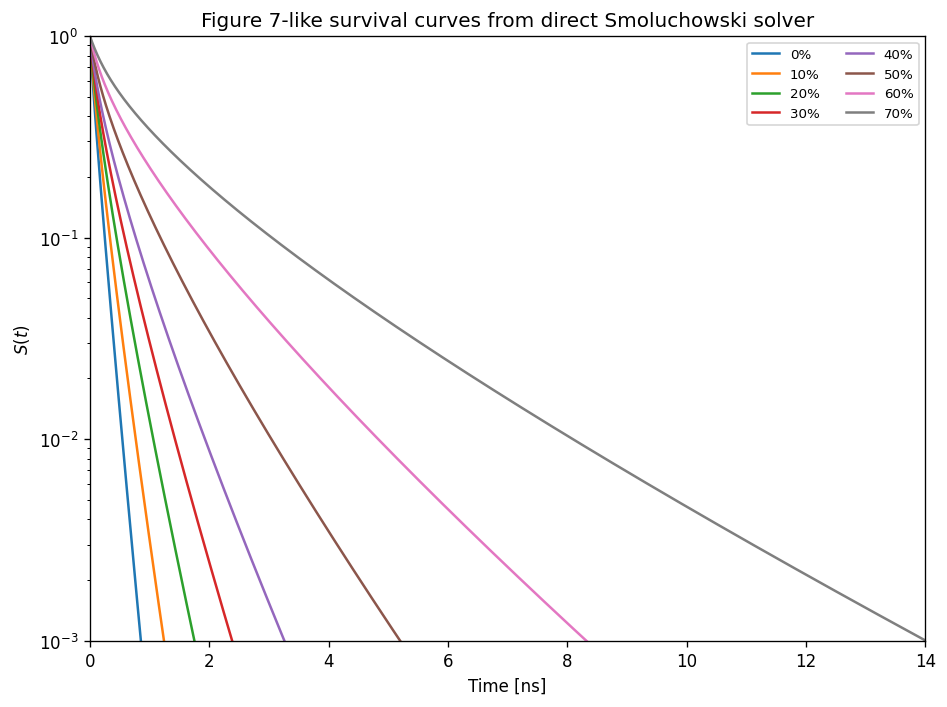

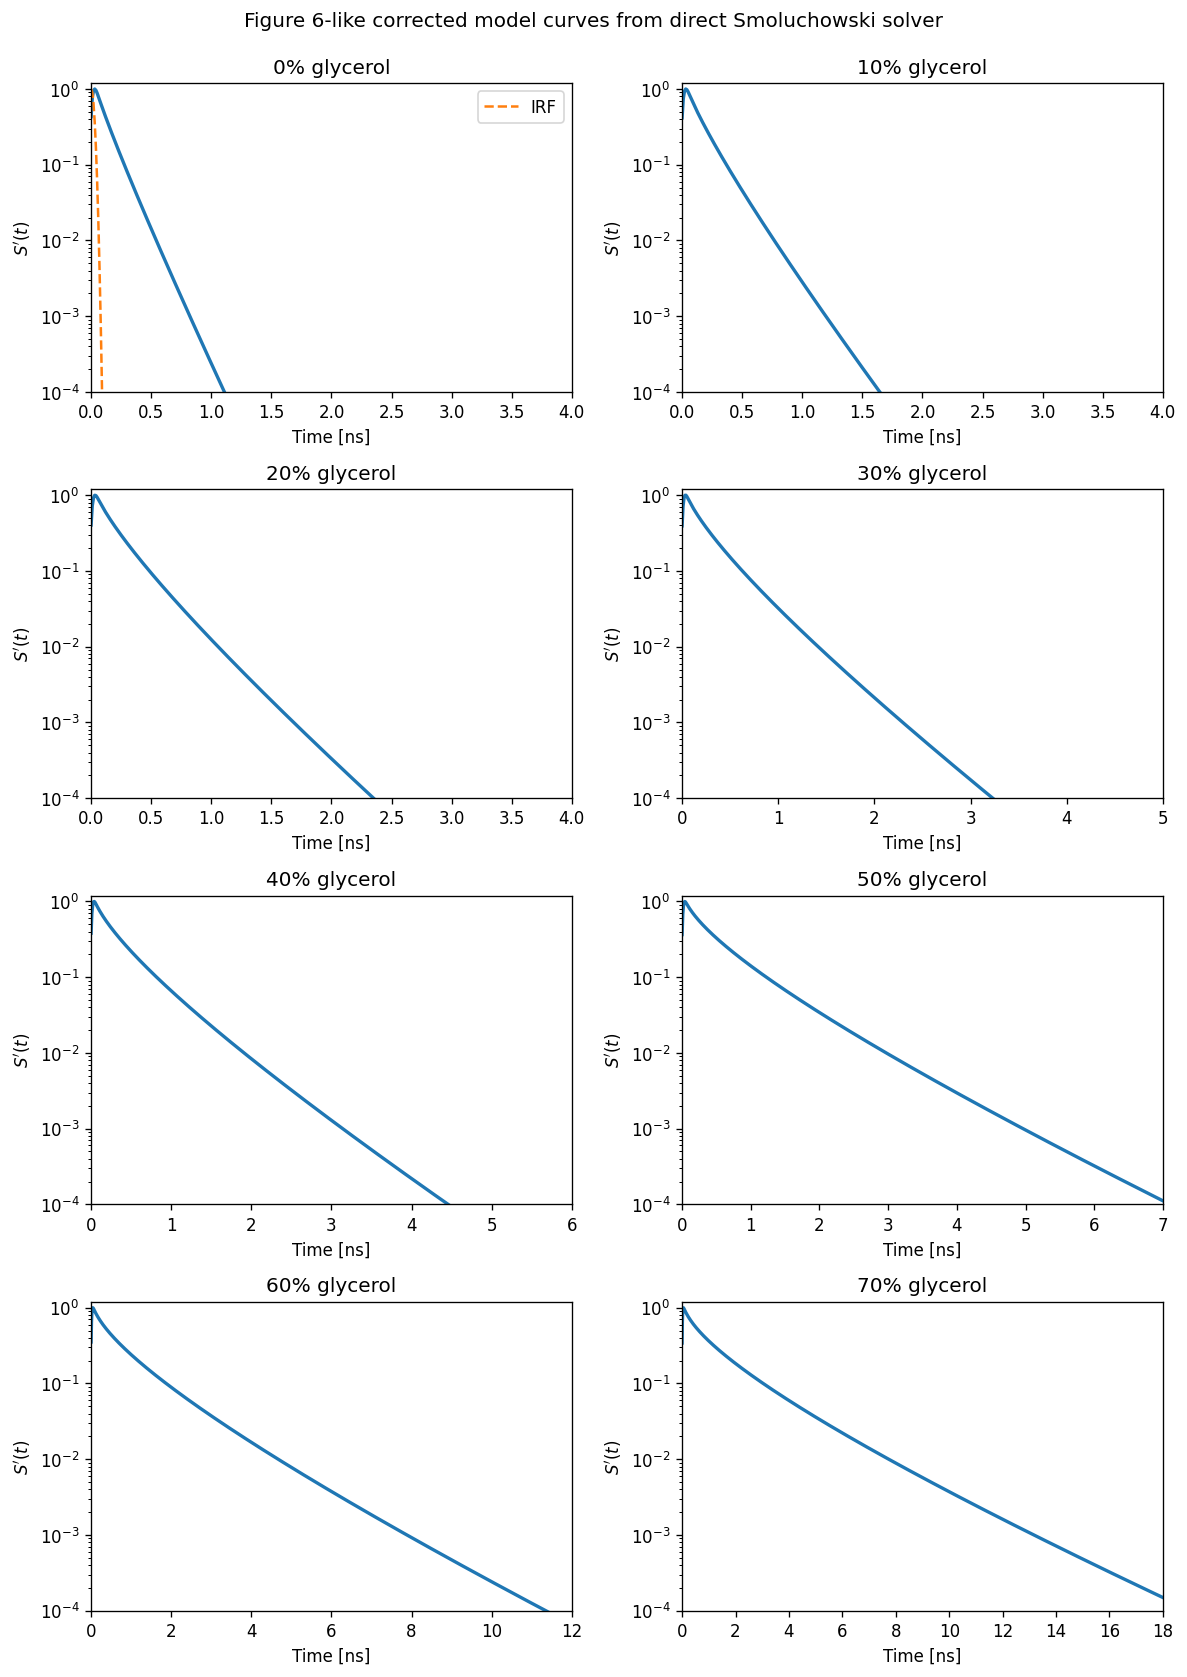

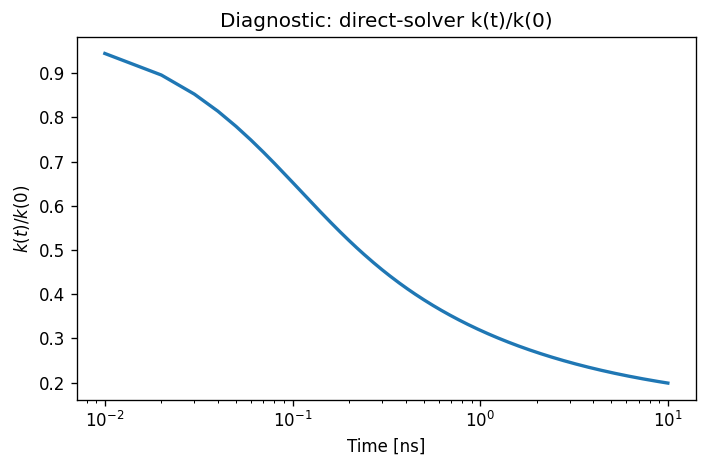

Direct Smoluchowski targets ready: len(t_ns)=1800, expected N_plot with fit_stride=8 is 225


In [4]:
# ============================================================
# Colab-ready reproduction of the MODEL CURVES in Figures 6 and 7
# from:
# Cohen, Huppert, Agmon
# "Diffusion-Limited Acid-Base Nonexponential Dynamics"
# J. Phys. Chem. A 2001, 105, 7165-7173
#
# This code solves eqs. (2)-(6) directly by method-of-lines.
# It does NOT use the paper's approximate k(t) shortcut.
#
# What it reproduces:
#   - Figure 7-like survival curves S(t)
#   - Figure 6-like corrected curves S'(t)=exp(-k_d t) S(t),
#     optionally convolved with a Gaussian IRF
#
# What it does NOT reproduce:
#   - the experimental dots, because the raw data are not in the PDF
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import fftconvolve

# ------------------------------------------------------------
# 1) Parameters from the paper
# ------------------------------------------------------------

# Table 1
vol_pct = np.array([0, 10, 20, 30, 40, 50, 60, 70], dtype=float)
mol_pct = np.array([0.00, 3.00, 5.82, 9.72, 14.0, 20.2, 26.9, 36.9], dtype=float)
eps_r   = np.array([78, 74, 71, 68, 65, 61, 58, 53], dtype=float)

# Table 1, fitted mutual diffusion coefficient D
# paper units: 1e-5 cm^2/s
# convenient conversion: 1e-5 cm^2/s = 1 nm^2/ns
D_nm2_ns = np.array([0.97, 0.45, 0.26, 0.17, 0.115, 0.067, 0.040, 0.023], dtype=float)

# Table 1, k_d in the presence of 2 M NaClO4
# paper units: 1e8 s^-1
# convert to ns^-1: 1e8 s^-1 = 0.1 ns^-1
kd_ns = 0.1 * np.array([8.1, 4.7, 3.0, 2.0, 1.3, 0.8, 0.5, 0.3], dtype=float)

# Table 1, "RD" values in Angstrom
# These are the values used in eq. (7)
RD_nm = np.array([7.1, 7.5, 7.8, 8.1, 8.5, 9.1, 9.5, 10.0], dtype=float) / 10.0

# Paper constants
a_nm = 0.7               # contact radius = 7 A
cB_M = 2.0               # fixed acetate concentration in Figs 6-7
tau0_ns = 10.0           # used by the paper in the correction step
irf_fwhm_ns = 0.05       # ~50 ps IRF width

# Fixed intrinsic proton-transfer rate used in Fig. 6 fits
# paper value: kPT = 9.4e9 M^-1 s^-1
kPT_Minv_s = 9.4e9

# 1 M = 0.602214076 molecules / nm^3
M_TO_NM3 = 0.602214076
nB = cB_M * M_TO_NM3      # number density in nm^-3

# Convert kPT from M^-1 s^-1 to nm^3/ns
# because rate = k * number_density
kPT_nm3_ns = kPT_Minv_s / (M_TO_NM3 * 1e9)

# Panel limits chosen to resemble the published figure layout
panel_tmax = [4, 4, 4, 5, 6, 7, 12, 18]

# ------------------------------------------------------------
# 2) Debye-Huckel screened Coulomb potential from eq. (7)
# ------------------------------------------------------------

def debye_length_nm(eps_rel, ionic_strength_M=2.0, T=298.15):
    """
    Approximate Debye screening length in nm.
    This is consistent with the scale implied by the paper at 2 M salt.
    """
    return 0.304 * np.sqrt((eps_rel / 78.5) * (T / 298.15)) / np.sqrt(ionic_strength_M)

def betaU(r_nm, a_nm, RD_nm_val, eps_rel, ionic_strength_M=2.0):
    """
    Eq. (7) in dimensionless form:

        beta U(r) = (RD / r) * exp[-kappa (r-a)] / (1 + kappa a)

    where RD is taken from Table 1 and kappa^{-1} is the Debye length.
    """
    lamD = debye_length_nm(eps_rel, ionic_strength_M=ionic_strength_M)
    kappa = 1.0 / lamD
    return (RD_nm_val / r_nm) * np.exp(-kappa * (r_nm - a_nm)) / (1.0 + kappa * a_nm)

# ------------------------------------------------------------
# 3) Direct solver for eqs. (4)-(6) using y = exp(beta U) p
# ------------------------------------------------------------

def solve_smolu_survival(
    D_nm2_ns,
    eps_rel,
    RD_nm_val,
    kd_this_ns,
    t_eval,
    Rmax_nm=25.0,
    Ncells=220,
    method="Radau",
    rtol=5e-6,
    atol=1e-8,
):
    """
    Solve the radial Smoluchowski problem directly.

    We use the transformed variable
        y(r,t) = exp(beta U(r)) * p(r,t)

    Then:
      - initial condition becomes y(r,0) = 1
      - inner radiation BC becomes a Robin BC for y
      - outer boundary is y(Rmax,t)=1 (bath equilibrium)

    Returns:
        k_t   : time-dependent rate coefficient k(t) in nm^3/ns
        S_t   : survival probability from eq. (2)
        Sp_t  : corrected survival S'(t)=exp(-k_d t) S(t) from eq. (15)
    """

    # Uniform finite-volume mesh on [a, Rmax]
    dr = (Rmax_nm - a_nm) / Ncells
    r_faces = a_nm + np.arange(Ncells + 1) * dr
    r_centers = a_nm + (np.arange(Ncells) + 0.5) * dr

    # Potential at centers/faces
    Uc = betaU(r_centers, a_nm, RD_nm_val, eps_rel, ionic_strength_M=cB_M)
    Uf = betaU(r_faces,   a_nm, RD_nm_val, eps_rel, ionic_strength_M=cB_M)
    Ua = betaU(a_nm,      a_nm, RD_nm_val, eps_rel, ionic_strength_M=cB_M)

    # q(r) = r^2 exp(-beta U(r))
    q_faces = r_faces**2 * np.exp(-Uf)

    # PDE for y:
    # y_t = D * exp(U)/r^2 * d/dr [ r^2 exp(-U) y_r ]
    A_centers = D_nm2_ns * np.exp(Uc) / (r_centers**2)

    # Robin coefficient at r=a:
    # 4 pi D a^2 y_r(a,t) = kPT * y(a,t)
    alpha = kPT_nm3_ns / (4.0 * np.pi * D_nm2_ns * a_nm**2)   # 1/nm

    def rhs(t, y):
        """
        Semi-discrete ODE system for y at cell centers.
        """
        F = np.empty(Ncells + 1)

        # ----- inner face at r=a -----
        # linear half-cell reconstruction + Robin BC
        # y_a = y(a,t)
        y_a = y[0] / (1.0 + alpha * dr / 2.0)
        y_r_a = alpha * y_a
        F[0] = q_faces[0] * y_r_a

        # ----- interior faces -----
        F[1:Ncells] = q_faces[1:Ncells] * (y[1:] - y[:-1]) / dr

        # ----- outer face at r=Rmax -----
        # impose y(Rmax,t)=1 with half-cell linear closure
        F[Ncells] = q_faces[Ncells] * (1.0 - y[-1]) / (dr / 2.0)

        # divergence of flux
        dydt = A_centers * (F[1:] - F[:-1]) / dr
        return dydt

    # Initial condition: p(r,0)=exp(-U), so y(r,0)=1
    y0 = np.ones(Ncells)

    sol = solve_ivp(
        rhs,
        (t_eval[0], t_eval[-1]),
        y0,
        t_eval=t_eval,
        method=method,
        rtol=rtol,
        atol=atol,
    )

    if not sol.success:
        raise RuntimeError(f"ODE solver failed: {sol.message}")

    y = sol.y

    # Reconstruct y(a,t) and p(a,t)
    y_a_t = y[0, :] / (1.0 + alpha * dr / 2.0)
    p_a_t = np.exp(-Ua) * y_a_t

    # Eq. (3): k(t)=kPT p(a,t)
    k_t = kPT_nm3_ns * p_a_t

    # Eq. (2): S(t)=exp[- c_B \int_0^t k(t') dt' ]
    expo = nB * np.concatenate([
        [0.0],
        np.cumsum(0.5 * (k_t[1:] + k_t[:-1]) * np.diff(t_eval))
    ])
    S_t = np.exp(-expo)

    # Eq. (15): S'(t)=exp(-k_d t) S(t)
    Sp_t = np.exp(-kd_this_ns * t_eval) * S_t

    return k_t, S_t, Sp_t

# ------------------------------------------------------------
# 4) IRF for Figure 6-like convolved model curves
# ------------------------------------------------------------

def gaussian_irf(t_ns, fwhm_ns=0.05):
    sigma = fwhm_ns / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    g = np.exp(-0.5 * (t_ns / sigma)**2)
    g /= np.trapz(g, t_ns)
    return g

def causal_convolution(signal, irf, dt):
    out = dt * fftconvolve(signal, irf, mode="full")[:len(signal)]
    return out

# ------------------------------------------------------------
# 5) Solve all compositions
# ------------------------------------------------------------

t_ns = np.linspace(0.0, 18.0, 1800)
dt = t_ns[1] - t_ns[0]

all_k  = []
all_S  = []
all_Sp = []
all_Sp_conv = []

for i in range(len(vol_pct)):
    k_t, S_t, Sp_t = solve_smolu_survival(
        D_nm2_ns=D_nm2_ns[i],
        eps_rel=eps_r[i],
        RD_nm_val=RD_nm[i],
        kd_this_ns=kd_ns[i],
        t_eval=t_ns,
        Rmax_nm=25.0,   # can increase to 30-40 for extra safety
        Ncells=220,     # can increase to 300 if you want more accuracy
    )

    all_k.append(k_t)
    all_S.append(S_t)
    all_Sp.append(Sp_t)

irf_t = t_ns.copy()
irf = gaussian_irf(irf_t, fwhm_ns=irf_fwhm_ns)

for i in range(len(vol_pct)):
    conv = causal_convolution(all_Sp[i], irf, dt)
    conv /= conv.max()
    all_Sp_conv.append(conv)

# ------------------------------------------------------------
# 6) Plot Figure 7-like model curves: S(t)
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(len(vol_pct)):
    ax.semilogy(t_ns, all_S[i], lw=1.5, label=f"{int(vol_pct[i])}%")

ax.set_xlim(0, 14)
ax.set_ylim(1e-3, 1.0)
ax.set_xlabel("Time [ns]")
ax.set_ylabel(r"$S(t)$")
ax.set_title("Figure 7-like survival curves from direct Smoluchowski solver")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7) Plot Figure 6-like model curves: S'(t) convolved with IRF
# ------------------------------------------------------------

fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes = axes.ravel()

for i, ax in enumerate(axes):
    mask = t_ns <= panel_tmax[i]
    ax.semilogy(t_ns[mask], all_Sp_conv[i][mask], lw=2)
    ax.set_xlim(0, panel_tmax[i])
    ax.set_ylim(1e-4, 1.2)
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel(r"$S'(t)$")
    ax.set_title(f"{int(vol_pct[i])}% glycerol")

    if i == 0:
        # scaled IRF shown only in first panel
        irf_scaled = irf / irf.max()
        ax.semilogy(irf_t[mask], irf_scaled[mask], "--", lw=1.5, label="IRF")
        ax.legend()

fig.suptitle("Figure 6-like corrected model curves from direct Smoluchowski solver", y=0.995)
fig.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8) Optional: inspect k(t)/k(0), like the paper's Figure 8
# ------------------------------------------------------------

# 50 vol% glycerol corresponds to ~20.2 mol% glycerol, close to the paper's Figure 8 case
idx = np.where(vol_pct == 50)[0][0]

fig, ax = plt.subplots(figsize=(6, 4))
mask = (t_ns > 0) & (t_ns <= 10)
ax.plot(t_ns[mask], (all_k[idx] / all_k[idx][0])[mask], lw=2)
ax.set_xscale("log")
ax.set_xlabel("Time [ns]")
ax.set_ylabel(r"$k(t)/k(0)$")
ax.set_title("Diagnostic: direct-solver k(t)/k(0)")
plt.tight_layout()
plt.show()

# Sanity check for the manuscript global-fit cell below.
print(f"Direct Smoluchowski targets ready: len(t_ns)={len(t_ns)}, expected N_plot with fit_stride=8 is {len(t_ns[::8])}")


## 4. Figure 2: 70% glycerol acid--base kernel comparison

Target glycerol = 70%
Target quantity = S(t)
N_fit = 450, dt = 0.0400222 ns
FIT_LAMBDA0 = False

FITTING: gamma
start 0: cost = 0.26253221
start 1: cost = 0.26253221
start 2: cost = 0.26253221

FITTING: exponential
start 0: cost = 1.56313916
start 1: cost = 1.56313916
start 2: cost = 1.56313916

FITTING: delay
start 0: cost = 4.01424863
start 1: cost = 4.07105230
start 2: cost = 8.43994250

MODEL COMPARISON
      model     cost  rel_err_S  rmse_logS  lambda0       Q0    A_loc      k_q    tau_q    tau_d  n_params  delta_cost
      gamma 0.262532   0.037577   0.025250      0.0 3.179188 0.273985 0.128179 0.161882      NaN         4    0.000000
exponential 1.563139   0.082035   0.068395      0.0 1.123243 0.307083      NaN 0.561369      NaN         3    1.300607
      delay 4.014249   0.141793   0.109648      0.0 0.790368 0.287671      NaN      NaN 0.840467         3    3.751716

BEST MODEL: gamma
theta_best = [3.17918828 0.27398457 0.12817867 0.16188158]

BEST PARAMETERS
     lambda0 = 0.0

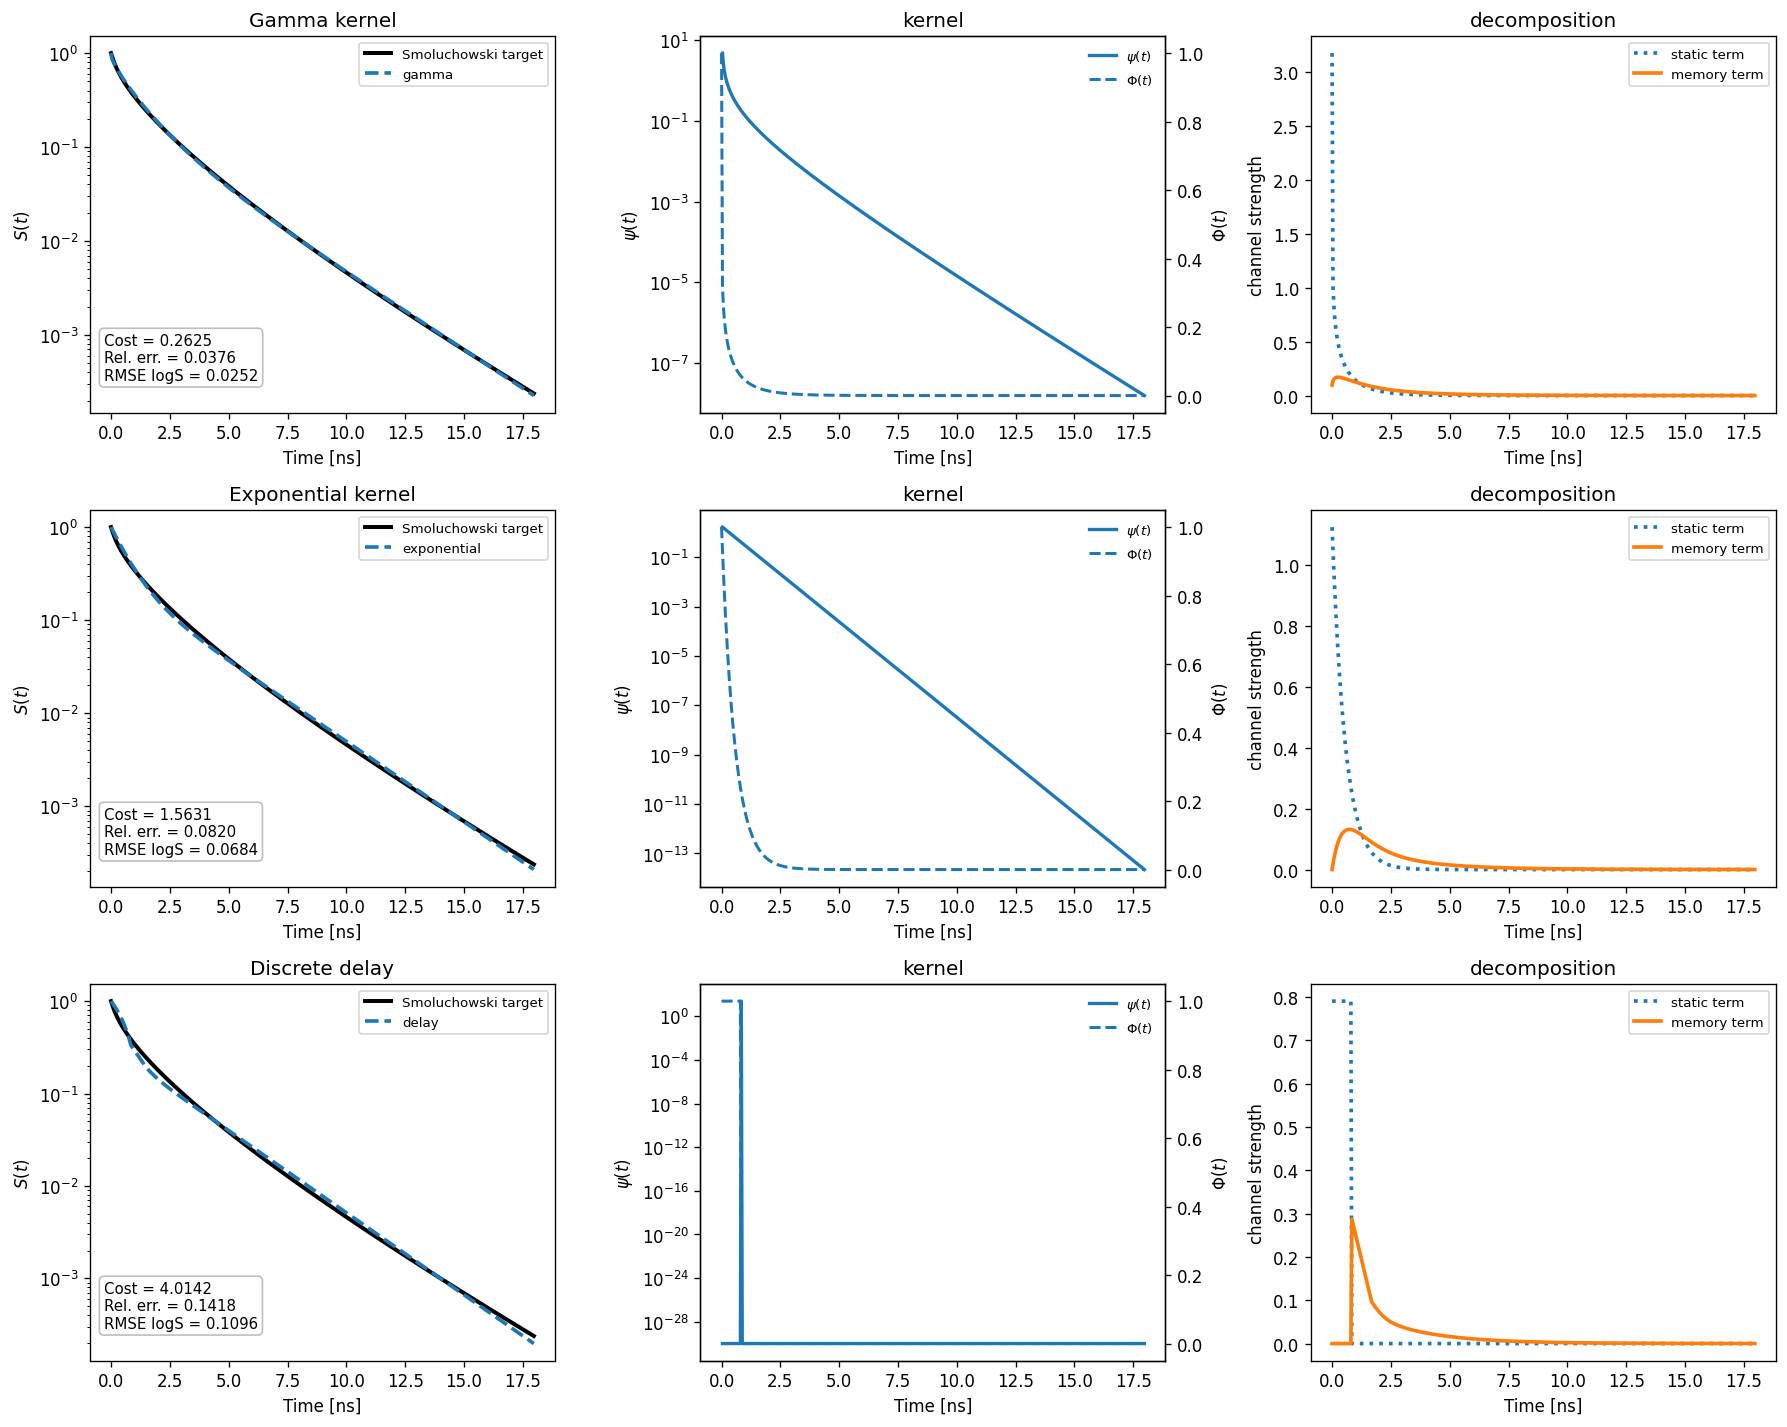

Saved: figures/figure2_acid_70pct_kernel_comparison.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import least_squares
from scipy.special import gammaln, gammaincc

# ============================================================
# ACID CASE — FIT GAMMA, EXPONENTIAL, AND DISCRETE DELAY
# USING THE SAME REDUCED FRAMEWORK AS IN ET
#
# Model:
#   dS/dt = -lambda0 * S - q(t)
#
#   q(t) = Q0 * Phi(t) + A_loc * ∫_0^t psi(t-s) S(s) ds
#
# Kernels compared:
#   1) gamma
#   2) exponential  : exact special case k_q = 1
#   3) delay        : exact discrete delay
#
# If fitting the pure Smoluchowski survival S(t), set FIT_LAMBDA0 = False.
# If fitting corrected/experimental-like S'(t), you may set FIT_LAMBDA0 = True.
#
# Assumes already available:
#   vol_pct, t_ns, all_S
# Optional:
#   all_Sp
# ============================================================

# ------------------------------------------------------------
# choose target
# ------------------------------------------------------------

target_glycerol = 70
use_corrected = False
fit_stride = 4

vol_pct_arr = np.asarray(vol_pct, dtype=float)
idx_target = np.where(vol_pct_arr == float(target_glycerol))[0]
if len(idx_target) == 0:
    raise RuntimeError(f"target_glycerol={target_glycerol} not found in vol_pct")
idx_target = int(idx_target[0])

t_fit = np.asarray(t_ns[::fit_stride], dtype=float)
S_target = np.asarray((all_Sp if use_corrected else all_S)[idx_target][::fit_stride], dtype=float)

dt = float(t_fit[1] - t_fit[0])
eps = 1e-14

# If target is pure S(t), usually keep lambda0 = 0.
# If target is corrected/experimental-like S'(t), you may fit lambda0.
FIT_LAMBDA0 = bool(use_corrected)

print(f"Target glycerol = {target_glycerol}%")
print(f"Target quantity = {'Sprime' if use_corrected else 'S'}(t)")
print(f"N_fit = {len(t_fit)}, dt = {dt:.6g} ns")
print(f"FIT_LAMBDA0 = {FIT_LAMBDA0}")

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------

def build_gamma_pdf_on_grid(k_shape, theta_k, t_grid):
    if k_shape <= 0 or theta_k <= 0:
        return None

    t = np.asarray(t_grid, dtype=float).copy()
    if len(t) < 2:
        return None

    tt = t.copy()
    tt[0] = max(0.5 * (t[1] - t[0]), 1e-12)
    tt[1:] = np.clip(tt[1:], 1e-300, None)

    with np.errstate(over="ignore", under="ignore", invalid="ignore"):
        log_pdf = (
            (k_shape - 1.0) * np.log(tt)
            - tt / theta_k
            - gammaln(k_shape)
            - k_shape * np.log(theta_k)
        )
        pdf = np.exp(log_pdf)

    if np.any(~np.isfinite(pdf)) or np.any(pdf < 0):
        return None

    Z = np.trapezoid(pdf, t)
    if (not np.isfinite(Z)) or Z <= 0:
        return None

    return pdf / Z

def build_gamma_psi_phi(k_q, tau_q, t_grid):
    if k_q <= 0 or tau_q <= 0:
        return None, None

    theta_q = tau_q / k_q
    psi_q = build_gamma_pdf_on_grid(k_q, theta_q, t_grid)
    if psi_q is None:
        return None, None

    t = np.asarray(t_grid, dtype=float)
    Phi_q = gammaincc(k_q, np.clip(t / theta_q, 0.0, None))

    if np.any(~np.isfinite(Phi_q)) or np.any(Phi_q < 0) or np.any(Phi_q > 1.000001):
        return None, None

    return psi_q, Phi_q

def delayed_value_zero_prehistory(t_query, t_hist, y_hist):
    if t_query < 0:
        return 0.0
    if t_query <= t_hist[0]:
        return float(y_hist[0])
    if t_query >= t_hist[-1]:
        return float(y_hist[-1])
    return float(np.interp(t_query, t_hist, y_hist))

def unpack_theta(theta, model_name):
    if FIT_LAMBDA0:
        lambda0 = float(theta[0])
        core = theta[1:]
    else:
        lambda0 = 0.0
        core = theta

    if model_name == "gamma":
        Q0, A_loc, k_q, tau_q = core
        return lambda0, Q0, A_loc, k_q, tau_q
    elif model_name == "exponential":
        Q0, A_loc, tau_q = core
        return lambda0, Q0, A_loc, 1.0, tau_q
    elif model_name == "delay":
        Q0, A_loc, tau_d = core
        return lambda0, Q0, A_loc, None, tau_d
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

# ------------------------------------------------------------
# simulation
# ------------------------------------------------------------

def simulate_gamma(theta, t_grid):
    lambda0, Q0, A_loc, k_q, tau_q = unpack_theta(theta, "gamma")

    if lambda0 < 0 or Q0 < 0 or A_loc < 0 or k_q <= 0 or tau_q <= 0:
        return None

    psi_q, Phi_q = build_gamma_psi_phi(k_q, tau_q, t_grid)
    if psi_q is None or Phi_q is None:
        return None

    n = len(t_grid)
    dt_local = float(t_grid[1] - t_grid[0])

    S = np.zeros(n, dtype=float)
    q_hist = np.zeros(n, dtype=float)
    static_hist = np.zeros(n, dtype=float)
    dyn_hist = np.zeros(n, dtype=float)

    S[0] = 1.0

    for i in range(1, n):
        conv_prev = dt_local * np.dot(psi_q[:i], S[i-1::-1])
        static_prev = Q0 * Phi_q[i-1]
        q_prev = static_prev + A_loc * conv_prev

        q_hist[i-1] = q_prev
        static_hist[i-1] = static_prev
        dyn_hist[i-1] = A_loc * conv_prev

        dS = -lambda0 * S[i-1] - q_prev
        S[i] = S[i-1] + dt_local * dS
        S[i] = np.clip(S[i], 1e-15, 1.0)

    conv_last = dt_local * np.dot(psi_q[:n], S[n-1::-1])
    q_hist[-1] = Q0 * Phi_q[-1] + A_loc * conv_last
    static_hist[-1] = Q0 * Phi_q[-1]
    dyn_hist[-1] = A_loc * conv_last

    return {
        "S": S,
        "q": q_hist,
        "static": static_hist,
        "dynamic": dyn_hist,
        "psi": psi_q,
        "Phi": Phi_q,
        "pars": {
            "lambda0": lambda0,
            "Q0": Q0,
            "A_loc": A_loc,
            "k_q": k_q,
            "tau_q": tau_q,
        },
    }

def simulate_exponential(theta, t_grid):
    lambda0, Q0, A_loc, _, tau_q = unpack_theta(theta, "exponential")

    if lambda0 < 0 or Q0 < 0 or A_loc < 0 or tau_q <= 0:
        return None

    n = len(t_grid)
    dt_local = float(t_grid[1] - t_grid[0])

    psi = (1.0 / tau_q) * np.exp(-t_grid / tau_q)
    Phi = np.exp(-t_grid / tau_q)

    S = np.zeros(n, dtype=float)
    q = np.zeros(n, dtype=float)
    static_hist = np.zeros(n, dtype=float)
    dyn_hist = np.zeros(n, dtype=float)

    S[0] = 1.0
    q[0] = Q0

    for i in range(1, n):
        dq = (A_loc * S[i-1] - q[i-1]) / tau_q
        q[i] = q[i-1] + dt_local * dq
        q[i] = max(q[i], 0.0)

        static_hist[i-1] = Q0 * Phi[i-1]
        dyn_hist[i-1] = max(q[i-1] - static_hist[i-1], 0.0)

        dS = -lambda0 * S[i-1] - q[i-1]
        S[i] = S[i-1] + dt_local * dS
        S[i] = np.clip(S[i], 1e-15, 1.0)

    static_hist[-1] = Q0 * Phi[-1]
    dyn_hist[-1] = max(q[-1] - static_hist[-1], 0.0)

    return {
        "S": S,
        "q": q,
        "static": static_hist,
        "dynamic": dyn_hist,
        "psi": psi,
        "Phi": Phi,
        "pars": {
            "lambda0": lambda0,
            "Q0": Q0,
            "A_loc": A_loc,
            "tau_q": tau_q,
        },
    }

def simulate_delay(theta, t_grid):
    lambda0, Q0, A_loc, _, tau_d = unpack_theta(theta, "delay")

    if lambda0 < 0 or Q0 < 0 or A_loc < 0 or tau_d < 0:
        return None

    n = len(t_grid)
    dt_local = float(t_grid[1] - t_grid[0])

    S = np.zeros(n, dtype=float)
    q = np.zeros(n, dtype=float)
    static_hist = np.zeros(n, dtype=float)
    dyn_hist = np.zeros(n, dtype=float)

    S[0] = 1.0

    for i in range(1, n):
        t_prev = t_grid[i-1]

        H_static = 1.0 if t_prev <= tau_d else 0.0
        static_prev = Q0 * H_static

        if t_prev >= tau_d:
            S_delay = delayed_value_zero_prehistory(t_prev - tau_d, t_grid[:i], S[:i])
        else:
            S_delay = 0.0

        dyn_prev = A_loc * S_delay
        q_prev = static_prev + dyn_prev

        static_hist[i-1] = static_prev
        dyn_hist[i-1] = dyn_prev
        q[i-1] = q_prev

        dS = -lambda0 * S[i-1] - q_prev
        S[i] = S[i-1] + dt_local * dS
        S[i] = np.clip(S[i], 1e-15, 1.0)

    t_last = t_grid[-1]
    H_static = 1.0 if t_last <= tau_d else 0.0
    static_hist[-1] = Q0 * H_static
    if t_last >= tau_d:
        dyn_hist[-1] = A_loc * delayed_value_zero_prehistory(t_last - tau_d, t_grid, S)
    else:
        dyn_hist[-1] = 0.0
    q[-1] = static_hist[-1] + dyn_hist[-1]

    psi_display = np.zeros_like(t_grid, dtype=float)
    if tau_d <= t_grid[-1]:
        idx = int(np.argmin(np.abs(t_grid - tau_d)))
        psi_display[idx] = 1.0 / max(dt_local, 1e-15)

    Phi_display = (t_grid <= tau_d).astype(float)

    return {
        "S": S,
        "q": q,
        "static": static_hist,
        "dynamic": dyn_hist,
        "psi": psi_display,
        "Phi": Phi_display,
        "pars": {
            "lambda0": lambda0,
            "Q0": Q0,
            "A_loc": A_loc,
            "tau_d": tau_d,
        },
    }

def simulate_model(theta, model_name, t_grid):
    if model_name == "gamma":
        return simulate_gamma(theta, t_grid)
    elif model_name == "exponential":
        return simulate_exponential(theta, t_grid)
    elif model_name == "delay":
        return simulate_delay(theta, t_grid)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

# ------------------------------------------------------------
# residual
# ------------------------------------------------------------

weights_t = 1.0 + 4.0 * np.exp(-t_fit / 0.4)

def residual_model(theta, model_name):
    sim = simulate_model(theta, model_name, t_fit)
    if sim is None:
        return 1e6 * np.ones_like(S_target)

    S_pred = sim["S"]
    rr = weights_t * (
        np.log(np.clip(S_pred, eps, 1.0))
        - np.log(np.clip(S_target, eps, 1.0))
    )

    if np.any(~np.isfinite(rr)):
        return 1e6 * np.ones_like(S_target)

    return rr

# ------------------------------------------------------------
# fit specs
# ------------------------------------------------------------

if FIT_LAMBDA0:
    gamma_bounds = ([0.0, 0.0, 0.0, 0.01, 1e-5], [20.0, 20.0, 20.0, 20.0, 20.0])
    exp_bounds   = ([0.0, 0.0, 0.0, 1e-5],       [20.0, 20.0, 20.0, 20.0])
    dly_bounds   = ([0.0, 0.0, 0.0, 0.0],        [20.0, 20.0, 20.0, 20.0])

    fit_configs = {
        "gamma": {
            "bounds": gamma_bounds,
            "starts": [
                [0.00, 1.0, 0.2, 2.0, 0.6],
                [0.01, 1.5, 0.3, 3.0, 0.8],
                [0.00, 0.5, 0.1, 1.2, 1.2],
            ],
        },
        "exponential": {
            "bounds": exp_bounds,
            "starts": [
                [0.00, 1.0, 0.2, 0.8],
                [0.01, 1.5, 0.3, 1.0],
                [0.00, 0.5, 0.1, 0.4],
            ],
        },
        "delay": {
            "bounds": dly_bounds,
            "starts": [
                [0.00, 1.0, 0.2, 0.8],
                [0.01, 1.5, 0.3, 1.0],
                [0.00, 0.5, 0.1, 0.4],
            ],
        },
    }
else:
    fit_configs = {
        "gamma": {
            "bounds": ([0.0, 0.0, 0.01, 1e-5], [20.0, 20.0, 20.0, 20.0]),
            "starts": [
                [1.0, 0.2, 2.0, 0.6],
                [1.5, 0.3, 3.0, 0.8],
                [0.5, 0.1, 1.2, 1.2],
            ],
        },
        "exponential": {
            "bounds": ([0.0, 0.0, 1e-5], [20.0, 20.0, 20.0]),
            "starts": [
                [1.0, 0.2, 0.8],
                [1.5, 0.3, 1.0],
                [0.5, 0.1, 0.4],
            ],
        },
        "delay": {
            "bounds": ([0.0, 0.0, 0.0], [20.0, 20.0, 20.0]),
            "starts": [
                [1.0, 0.2, 0.8],
                [1.5, 0.3, 1.0],
                [0.5, 0.1, 0.4],
            ],
        },
    }

# ------------------------------------------------------------
# fit routine
# ------------------------------------------------------------

def fit_one_model(model_name, max_nfev=2500, verbose=0):
    spec = fit_configs[model_name]
    lb = np.array(spec["bounds"][0], dtype=float)
    ub = np.array(spec["bounds"][1], dtype=float)

    best_sol = None
    best_cost = np.inf

    print("\n" + "=" * 70)
    print("FITTING:", model_name)
    print("=" * 70)

    for j, x0 in enumerate(spec["starts"]):
        x0 = np.clip(np.array(x0, dtype=float), lb + 1e-12, ub - 1e-12)

        sol = least_squares(
            lambda th: residual_model(th, model_name),
            x0,
            bounds=(lb, ub),
            method="trf",
            max_nfev=max_nfev,
            xtol=1e-9,
            ftol=1e-9,
            gtol=1e-9,
            verbose=verbose,
        )

        print(f"start {j}: cost = {sol.cost:.8f}")

        if np.isfinite(sol.cost) and sol.cost < best_cost:
            best_sol = sol
            best_cost = sol.cost

    if best_sol is None:
        raise RuntimeError(f"All starts failed for {model_name}")

    sim_best = simulate_model(best_sol.x, model_name, t_fit)
    return best_sol, sim_best

# ------------------------------------------------------------
# run all three fits
# ------------------------------------------------------------

fit_results = {}
rows = []

for model_name in ["gamma", "exponential", "delay"]:
    sol, sim = fit_one_model(model_name, max_nfev=2500, verbose=0)
    fit_results[model_name] = {"sol": sol, "sim": sim}

    rel_err = np.linalg.norm(sim["S"] - S_target) / max(np.linalg.norm(S_target), 1e-15)
    rmse_logS = np.sqrt(np.mean(
        (np.log(np.clip(sim["S"], eps, 1.0)) - np.log(np.clip(S_target, eps, 1.0))) ** 2
    ))

    pars = sim["pars"]
    rows.append({
        "model": model_name,
        "cost": float(sol.cost),
        "rel_err_S": float(rel_err),
        "rmse_logS": float(rmse_logS),
        "lambda0": pars.get("lambda0", np.nan),
        "Q0": pars.get("Q0", np.nan),
        "A_loc": pars.get("A_loc", np.nan),
        "k_q": pars.get("k_q", np.nan),
        "tau_q": pars.get("tau_q", np.nan),
        "tau_d": pars.get("tau_d", np.nan),
        "n_params": len(sol.x),
    })

df_cmp = pd.DataFrame(rows).sort_values(["cost", "rel_err_S"]).reset_index(drop=True)
best_cost = float(df_cmp.iloc[0]["cost"])
df_cmp["delta_cost"] = df_cmp["cost"] - best_cost

print("\nMODEL COMPARISON")
print(df_cmp.round(8).to_string(index=False))

best_model = df_cmp.iloc[0]["model"]
best_sol = fit_results[best_model]["sol"]
best_sim = fit_results[best_model]["sim"]

print("\nBEST MODEL:", best_model)
print("theta_best =", best_sol.x)
print("\nBEST PARAMETERS")
for k, v in best_sim["pars"].items():
    print(f"{k:>12s} = {float(v):.8f}")

# ------------------------------------------------------------
# plots
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(15, 12), squeeze=False)
model_order = ["gamma", "exponential", "delay"]
panel_titles = ["Gamma kernel", "Exponential kernel", "Discrete delay"]

for r, model_name in enumerate(model_order):
    sim = fit_results[model_name]["sim"]

    ax = axes[r, 0]
    ax.semilogy(t_fit, S_target, "k", lw=2.4, label="Smoluchowski target")
    ax.semilogy(t_fit, sim["S"], "--", lw=2.2, label=model_name)
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel(r"$S(t)$")
    ax.set_title(panel_titles[r])
    ax.legend(fontsize=8)

    txt = (
        f"Cost = {fit_results[model_name]['sol'].cost:.4f}\n"
        f"Rel. err. = {df_cmp[df_cmp['model']==model_name]['rel_err_S'].values[0]:.4f}\n"
        f"RMSE logS = {df_cmp[df_cmp['model']==model_name]['rmse_logS'].values[0]:.4f}"
    )
    ax.text(
        0.03, 0.08, txt,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

    ax = axes[r, 1]
    ax.semilogy(t_fit[1:], sim["psi"][1:] + 1e-30, lw=2.0, label=r"$\psi(t)$")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel(r"$\psi(t)$")
    ax.set_title("kernel")

    ax2 = ax.twinx()
    ax2.plot(t_fit, sim["Phi"], "--", lw=1.8, label=r"$\Phi(t)$")
    ax2.set_ylabel(r"$\Phi(t)$")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, frameon=False, loc="upper right")

    ax = axes[r, 2]
    ax.plot(t_fit, sim["static"], ":", lw=2.2, label="static term")
    ax.plot(t_fit, sim["dynamic"], lw=2.2, label="memory term")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("channel strength")
    ax.set_title("decomposition")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "figure2_acid_70pct_kernel_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "figure2_acid_70pct_kernel_comparison.pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'figure2_acid_70pct_kernel_comparison.png'}")


## 5. Figure 3: global acid--base fits across glycerol fractions

This cell uses the same global glycerol fit script used for the manuscript Figure 3 (`acid_base_three_kernel_fits.png`).

Global fit levels: [20.0, 30.0, 40.0, 50.0, 60.0, 70.0]
N_plot = 225, dt = 0.0800445 ns
FIT_ALPHA = True
max_fit_time_ns = 6
target_floor = 1e-10

FITTING MODEL: gamma


/tmp/ipykernel_11737/3755559062.py:156: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(pdf, t)


  start 0: cost = 6.14635304
  start 1: cost = 6.14635305
  start 2: cost = 6.14635305

BEST PARAMETERS
[0.0411477  0.54370717 0.73514967 0.12809622 6.60938062 5.44181406]

Per-glycerol parameters
 glycerol    tau_g      Q_g      A_g  rel_err
     20.0 0.084185 4.180241 1.521598 0.030118
     30.0 0.106063 3.711051 1.207738 0.034891
     40.0 0.131177 3.237002 0.976512 0.037941
     50.0 0.175964 2.536853 0.727967 0.038713
     60.0 0.232929 1.860666 0.549937 0.040895
     70.0 0.314698 1.192395 0.407045 0.073280

Summary
       model = gamma
        cost = 6.146353036819589
mean_rel_err = 0.0426396183276963
 max_rel_err = 0.07327965745510046
     tau_ref = 0.041147701048115236
       alpha = 0.5437071652780651
    k_shared = 0.7351496705354026
         c_A = 0.12809622381316937
      Q0_amp = 6.609380621493454
      Q0_lam = 5.441814063816438

FITTING MODEL: exponential


/tmp/ipykernel_11737/3755559062.py:184: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(psi, t)


  start 0: cost = 6.36152466
  start 1: cost = 6.36152466
  start 2: cost = 6.36152467

BEST PARAMETERS
[0.04886965 0.53875547 0.15019591 5.94415616 4.70636987]

Per-glycerol parameters
 glycerol    tau_g      Q_g      A_g  rel_err
     20.0 0.099334 3.724398 1.512026 0.048949
     30.0 0.124886 3.302405 1.202668 0.058783
     40.0 0.154158 2.877389 0.974297 0.062125
     50.0 0.206239 2.251893 0.728261 0.059411
     60.0 0.272308 1.650085 0.551566 0.058221
     70.0 0.366894 1.057249 0.409371 0.086483

Summary
       model = exponential
        cost = 6.361524656460742
mean_rel_err = 0.062328646258825594
 max_rel_err = 0.08648267392918504
     tau_ref = 0.048869648252800685
       alpha = 0.5387554694246761
    k_shared = nan
         c_A = 0.15019591020422843
      Q0_amp = 5.944156160135621
      Q0_lam = 4.706369872032632

FITTING MODEL: delay
  start 0: cost = 24.16710602
  start 1: cost = 18.96740437
  start 2: cost = 25.86416723

BEST PARAMETERS
[0.03529318 0.62196839 0.17373705

/tmp/ipykernel_11737/3755559062.py:156: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(pdf, t)
/tmp/ipykernel_11737/3755559062.py:184: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(psi, t)



Figure saved as: acid_base_three_kernel_fits.png


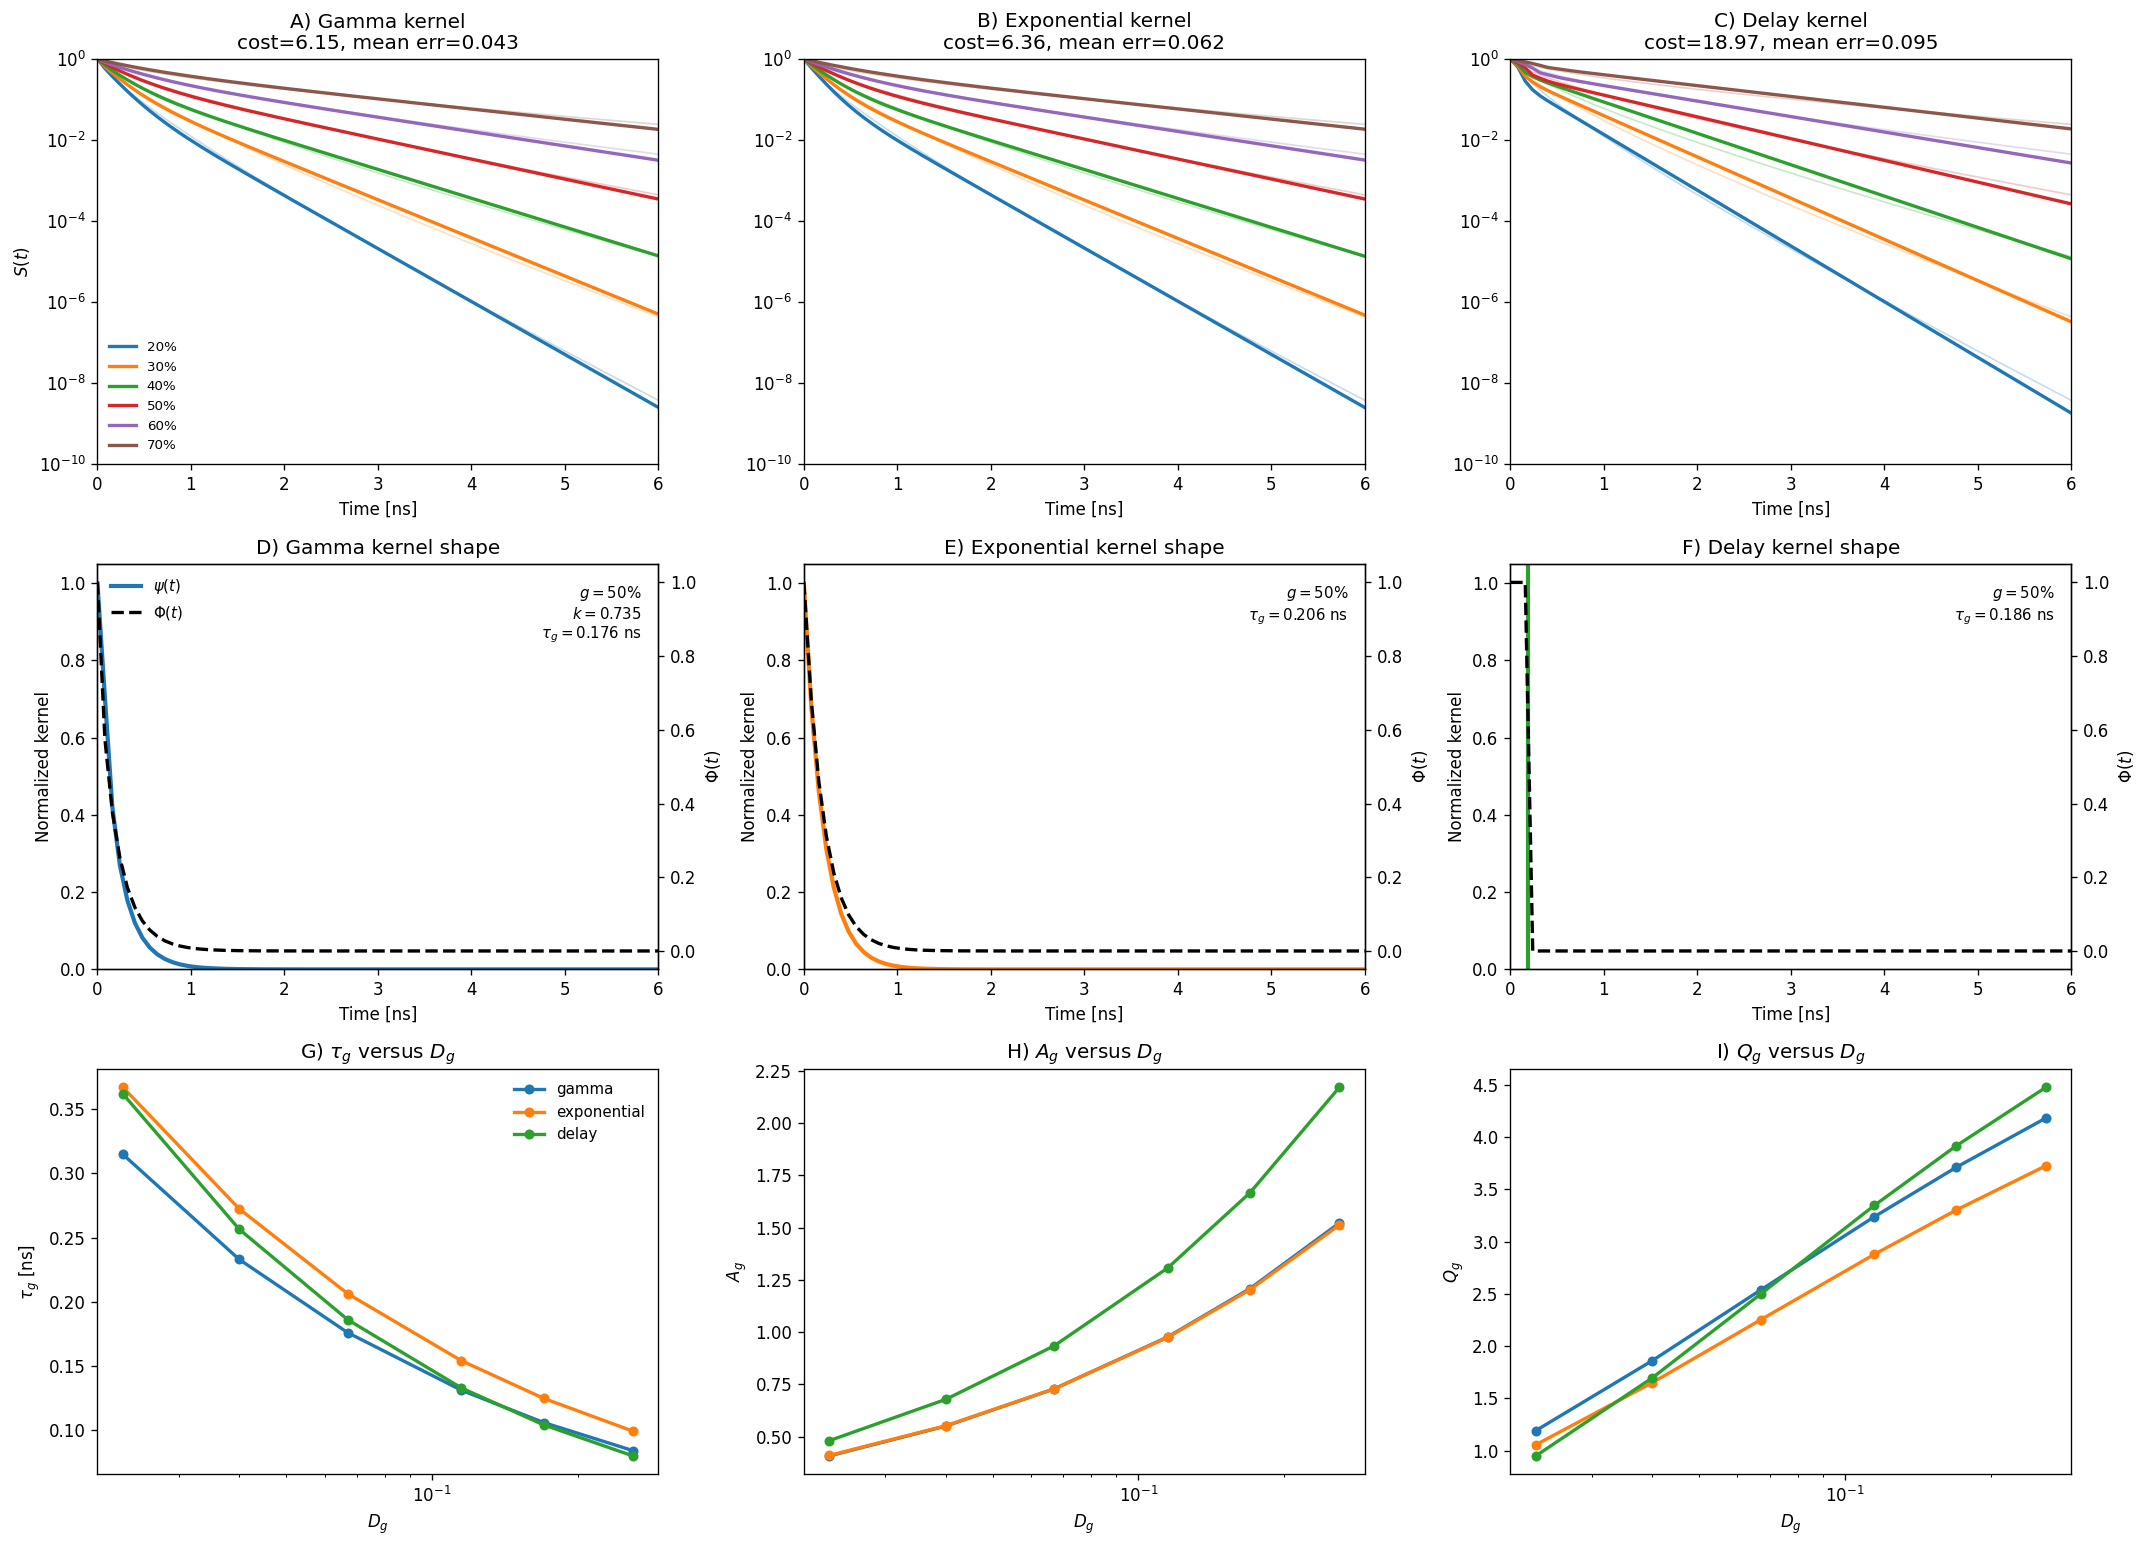

Copied to: figures/figure3_acid_base_global_three_kernel_fits.png


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.special import gammaln, gammaincc

# ============================================================
# ACID-BASE GLOBAL FIT
# Three kernels:
#   1) gamma
#   2) exponential
#   3) delay
#
# Shared closure:
#   tau_g = tau_ref * (D_ref / D_g)^alpha
#   A_g   = c_A / tau_g
#   Q_g   = Q0_amp * exp(-Q0_lam * tau_g)
#
# Model:
#   dS_g/dt = - q_g(t)
#   q_g(t)  = Q_g * Phi_g(t) + A_g * ∫_0^t psi_g(t-s) S_g(s) ds
#
# For delay:
#   psi_g(t) = delta(t - tau_g)
#   Phi_g(t) = H(tau_g - t)
#
# Assumes already in memory:
#   vol_pct, t_ns, all_S
# ============================================================

# ------------------------------------------------------------
# USER OPTIONS
# ------------------------------------------------------------

fit_stride = 8
global_fit_levels = [20.0, 30.0, 40.0, 50.0, 60.0, 70.0]

max_fit_time_ns = 6
target_floor = 1e-10

sim_floor = 1e-300
log_floor = 1e-300
max_nfev = 300

FIT_ALPHA = True
alpha_fixed = 0.60

save_figure = True
figure_name = "acid_base_three_kernel_fits.png"

# ------------------------------------------------------------
# BASIC CHECKS
# ------------------------------------------------------------

if "vol_pct" not in globals() or "t_ns" not in globals() or "all_S" not in globals():
    raise RuntimeError("Need vol_pct, t_ns, and all_S in memory.")

vol_pct_arr = np.asarray(vol_pct, dtype=float)
all_levels = sorted([float(v) for v in vol_pct_arr])

t_plot = np.asarray(t_ns[::fit_stride], dtype=float)
dt = float(t_plot[1] - t_plot[0])

targets = {}
for g in all_levels:
    idx = np.where(vol_pct_arr == g)[0]
    if len(idx) == 0:
        raise RuntimeError(f"Glycerol level {g} not found in vol_pct.")
    idx = int(idx[0])
    targets[g] = np.asarray(all_S[idx][::fit_stride], dtype=float)

fit_masks = {}
for g in global_fit_levels:
    mask = (t_plot <= max_fit_time_ns) & (targets[g] > target_floor)
    if np.sum(mask) < 15:
        raise RuntimeError(f"Too few fit points for glycerol {g}")
    fit_masks[g] = mask

print("Global fit levels:", global_fit_levels)
print(f"N_plot = {len(t_plot)}, dt = {dt:.6g} ns")
print(f"FIT_ALPHA = {FIT_ALPHA}")
if not FIT_ALPHA:
    print(f"alpha_fixed = {alpha_fixed}")
print(f"max_fit_time_ns = {max_fit_time_ns}")
print(f"target_floor = {target_floor:g}")

# Reproducibility guard: the manuscript Figure 3 was produced from the
# direct Smoluchowski target-generation cell above, where len(t_ns)=1800.
# With fit_stride=8 this gives N_plot=225 and dt≈0.0800445 ns.
if len(t_plot) != 225:
    raise RuntimeError(
        f"This cell is not using the manuscript grid: got N_plot={len(t_plot)}. "
        "Run the direct Smoluchowski acid-base target cell immediately above "
        "before running this global-fit cell."
    )

# ------------------------------------------------------------
# D VALUES FROM TABLE 1 (2 M NaAc)
# ------------------------------------------------------------

D_map = {
    0.0: 0.97,
    10.0: 0.45,
    20.0: 0.26,
    30.0: 0.17,
    40.0: 0.115,
    50.0: 0.067,
    60.0: 0.040,
    70.0: 0.023,
}

for g in global_fit_levels:
    if g not in D_map:
        raise RuntimeError(f"Missing D value for glycerol {g}")

D_ref = D_map[0.0]

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def safe_update(x):
    if (not np.isfinite(x)) or (x <= 0.0):
        return sim_floor
    if x > 1.0:
        return 1.0
    return x

def tau_g_from_D(D_g, tau_ref, alpha):
    return tau_ref * (D_ref / D_g) ** alpha

def build_gamma_pdf_on_grid(k_shape, theta_k, t_grid):
    if k_shape <= 0 or theta_k <= 0:
        return None

    t = np.asarray(t_grid, dtype=float).copy()
    if len(t) < 2:
        return None

    tt = t.copy()
    tt[0] = max(0.5 * (t[1] - t[0]), 1e-12)
    tt[1:] = np.clip(tt[1:], 1e-300, None)

    with np.errstate(over="ignore", under="ignore", invalid="ignore"):
        log_pdf = (
            (k_shape - 1.0) * np.log(tt)
            - tt / theta_k
            - gammaln(k_shape)
            - k_shape * np.log(theta_k)
        )
        pdf = np.exp(log_pdf)

    if np.any(~np.isfinite(pdf)) or np.any(pdf < 0):
        return None

    Z = np.trapz(pdf, t)
    if (not np.isfinite(Z)) or Z <= 0:
        return None

    return pdf / Z

def build_gamma_psi_phi(k_q, tau_q, t_grid):
    if k_q <= 0 or tau_q <= 0:
        return None, None

    theta_q = tau_q / k_q
    psi_q = build_gamma_pdf_on_grid(k_q, theta_q, t_grid)
    if psi_q is None:
        return None, None

    t = np.asarray(t_grid, dtype=float)
    Phi_q = gammaincc(k_q, np.clip(t / theta_q, 0.0, None))

    if np.any(~np.isfinite(Phi_q)):
        return None, None

    return psi_q, Phi_q

def build_exponential_psi_phi(tau_q, t_grid):
    if tau_q <= 0:
        return None, None
    t = np.asarray(t_grid, dtype=float)
    psi = (1.0 / tau_q) * np.exp(-t / tau_q)
    Z = np.trapz(psi, t)
    if (not np.isfinite(Z)) or Z <= 0:
        return None, None
    psi = psi / Z
    Phi = np.exp(-t / tau_q)
    return psi, Phi

def heaviside_survival(t, tau):
    return 1.0 if t < tau else 0.0

def delayed_value(t_delay, t_known, y_known):
    if t_delay <= 0:
        return 0.0
    return np.interp(t_delay, t_known, y_known)

# ------------------------------------------------------------
# PARAMETER UNPACKING
# ------------------------------------------------------------

def unpack_theta(theta, model_name):
    idx = 0
    tau_ref = float(theta[idx]); idx += 1

    if FIT_ALPHA:
        alpha = float(theta[idx]); idx += 1
    else:
        alpha = float(alpha_fixed)

    pars = {
        "tau_ref": tau_ref,
        "alpha": alpha,
    }

    if model_name == "gamma":
        pars["k_shared"] = float(theta[idx]); idx += 1

    pars["c_A"] = float(theta[idx]); idx += 1
    pars["Q0_amp"] = float(theta[idx]); idx += 1
    pars["Q0_lam"] = float(theta[idx]); idx += 1

    return pars

# ------------------------------------------------------------
# SIMULATION
# ------------------------------------------------------------

def simulate_model(theta, model_name):
    pars = unpack_theta(theta, model_name)

    tau_ref = pars["tau_ref"]
    alpha = pars["alpha"]
    c_A = pars["c_A"]
    Q0_amp = pars["Q0_amp"]
    Q0_lam = pars["Q0_lam"]

    if tau_ref <= 0 or alpha <= 0 or c_A < 0 or Q0_amp < 0 or Q0_lam < 0:
        return None

    if model_name == "gamma":
        k_shared = pars["k_shared"]
        if k_shared <= 0:
            return None

    curves = {}
    tau_by_g = {}
    A_by_g = {}
    Q_by_g = {}

    for g in global_fit_levels:
        D_g = D_map[g]
        tau_g = tau_g_from_D(D_g, tau_ref, alpha)
        A_g = c_A / tau_g
        Q_g = Q0_amp * np.exp(-Q0_lam * tau_g)

        if tau_g <= 0 or A_g < 0 or Q_g < 0:
            return None

        # Build kernel/survival objects
        if model_name == "gamma":
            psi, Phi = build_gamma_psi_phi(k_shared, tau_g, t_plot)
            if psi is None or Phi is None:
                return None
        elif model_name == "exponential":
            psi, Phi = build_exponential_psi_phi(tau_g, t_plot)
            if psi is None or Phi is None:
                return None
        elif model_name == "delay":
            psi, Phi = None, None
        else:
            raise ValueError(f"Unknown model_name = {model_name}")

        n = len(t_plot)
        S = np.zeros(n, dtype=float)
        q = np.zeros(n, dtype=float)
        static_hist = np.zeros(n, dtype=float)
        dynamic_hist = np.zeros(n, dtype=float)

        S[0] = 1.0

        for i in range(1, n):
            t_prev = t_plot[i - 1]

            # Static part
            if model_name == "delay":
                static_prev = Q_g * heaviside_survival(t_prev, tau_g)
            else:
                static_prev = Q_g * Phi[i - 1]

            # Dynamic part
            if model_name in ["gamma", "exponential"]:
                conv_prev = dt * np.dot(psi[:i], S[i - 1::-1])
                dynamic_prev = A_g * conv_prev
            else:  # delay
                if t_prev < tau_g:
                    dynamic_prev = 0.0
                else:
                    td = t_prev - tau_g
                    sdel = delayed_value(td, t_plot[:i], S[:i])
                    dynamic_prev = A_g * sdel

            q_prev = static_prev + dynamic_prev

            q[i - 1] = q_prev
            static_hist[i - 1] = static_prev
            dynamic_hist[i - 1] = dynamic_prev

            S[i] = safe_update(S[i - 1] - dt * q_prev)

        # Final q
        t_last = t_plot[-1]
        if model_name == "delay":
            static_last = Q_g * heaviside_survival(t_last, tau_g)
            if t_last < tau_g:
                dynamic_last = 0.0
            else:
                td = t_last - tau_g
                sdel = delayed_value(td, t_plot, S)
                dynamic_last = A_g * sdel
        else:
            conv_last = dt * np.dot(psi[:n], S[n - 1::-1])
            static_last = Q_g * Phi[-1]
            dynamic_last = A_g * conv_last

        q[-1] = static_last + dynamic_last
        static_hist[-1] = static_last
        dynamic_hist[-1] = dynamic_last

        tau_by_g[g] = tau_g
        A_by_g[g] = A_g
        Q_by_g[g] = Q_g

        curves[g] = {
            "S": S,
            "q": q,
            "static": static_hist,
            "dynamic": dynamic_hist,
        }

    return {
        "pars": pars,
        "tau_by_g": tau_by_g,
        "A_by_g": A_by_g,
        "Q_by_g": Q_by_g,
        "curves": curves,
    }

# ------------------------------------------------------------
# RESIDUALS
# ------------------------------------------------------------

def residual_model(theta, model_name):
    sim = simulate_model(theta, model_name)
    if sim is None:
        return 1e6 * np.ones(sum(np.sum(fit_masks[g]) for g in global_fit_levels), dtype=float)

    weights_t = 1.0 + 4.0 * np.exp(-t_plot / 0.4)
    #weights_t = np.ones_like(t_plot)
    #weights_t = 1.0 + 2.0 * np.exp(-t_plot / 0.8)
    residuals = []
    for g in global_fit_levels:
        mask = fit_masks[g]
        S_pred = sim["curves"][g]["S"][mask]
        S_tgt = targets[g][mask]

        rr = weights_t[mask] * (
            np.log(np.clip(S_pred, log_floor, None))
            - np.log(np.clip(S_tgt, log_floor, None))
        )

        if np.any(~np.isfinite(rr)):
            return 1e6 * np.ones(sum(np.sum(fit_masks[gg]) for gg in global_fit_levels), dtype=float)

        residuals.append(rr)

    return np.concatenate(residuals)

# ------------------------------------------------------------
# INITIAL GUESSES
# ------------------------------------------------------------

def make_start(model_name):
    tau_ref_guess = 0.046
    alpha_guess = 0.56
    c_A_guess = 0.144
    Q0_amp_guess = 6.28
    Q0_lam_guess = 4.74

    x0 = [tau_ref_guess]
    lb = [1e-5]
    ub = [1.0]

    if FIT_ALPHA:
        x0 += [alpha_guess]
        lb += [0.10]
        ub += [1.50]

    if model_name == "gamma":
        k_guess = 0.87
        x0 += [k_guess]
        lb += [0.05]
        ub += [3.0]

    x0 += [c_A_guess, Q0_amp_guess, Q0_lam_guess]
    lb += [1e-8, 0.0, 0.0]
    ub += [5.0, 50.0, 100.0]

    return np.array(x0, dtype=float), np.array(lb, dtype=float), np.array(ub, dtype=float)

# ------------------------------------------------------------
# FITTING ROUTINE
# ------------------------------------------------------------

def fit_one_model(model_name):
    x0, lb, ub = make_start(model_name)

    starts = [
        x0.copy(),
        np.clip(0.95 * x0, lb + 1e-12, ub - 1e-12),
        np.clip(1.05 * x0, lb + 1e-12, ub - 1e-12),
    ]

    best_sol = None
    best_cost = np.inf

    print("\n" + "=" * 72)
    print(f"FITTING MODEL: {model_name}")
    print("=" * 72)

    for j, xstart in enumerate(starts):
        sol = least_squares(
            residual_model,
            xstart,
            args=(model_name,),
            bounds=(lb, ub),
            method="trf",
            max_nfev=max_nfev,
            xtol=1e-8,
            ftol=1e-8,
            gtol=1e-8,
            x_scale="jac",
            verbose=0,
        )
        print(f"  start {j}: cost = {sol.cost:.8f}")

        if np.isfinite(sol.cost) and sol.cost < best_cost:
            best_sol = sol
            best_cost = sol.cost

    if best_sol is None:
        raise RuntimeError(f"Fit failed for model {model_name}")

    best_sim = simulate_model(best_sol.x, model_name)

    rows = []
    for g in global_fit_levels:
        mask = fit_masks[g]
        S_pred = best_sim["curves"][g]["S"][mask]
        S_tgt = targets[g][mask]
        rel_err = np.linalg.norm(S_pred - S_tgt) / max(np.linalg.norm(S_tgt), 1e-15)

        row = {
            "glycerol": g,
            "tau_g": best_sim["tau_by_g"][g],
            "Q_g": best_sim["Q_by_g"][g],
            "A_g": best_sim["A_by_g"][g],
            "rel_err": rel_err,
        }
        rows.append(row)

    df = pd.DataFrame(rows).sort_values("glycerol").reset_index(drop=True)

    summary = {
        "model": model_name,
        "cost": float(best_sol.cost),
        "mean_rel_err": float(df["rel_err"].mean()),
        "max_rel_err": float(df["rel_err"].max()),
        "tau_ref": float(best_sim["pars"]["tau_ref"]),
        "alpha": float(best_sim["pars"]["alpha"]),
        "k_shared": float(best_sim["pars"]["k_shared"]) if model_name == "gamma" else np.nan,
        "c_A": float(best_sim["pars"]["c_A"]),
        "Q0_amp": float(best_sim["pars"]["Q0_amp"]),
        "Q0_lam": float(best_sim["pars"]["Q0_lam"]),
    }

    print("\nBEST PARAMETERS")
    print(best_sol.x)

    print("\nPer-glycerol parameters")
    print(df.round(8).to_string(index=False))

    print("\nSummary")
    for k, v in summary.items():
        print(f"{k:>12s} = {v}")

    return {
        "sol": best_sol,
        "sim": best_sim,
        "df": df,
        "summary": summary,
    }

# ------------------------------------------------------------
# RUN ALL THREE
# ------------------------------------------------------------

results = {}
for model_name in ["gamma", "exponential", "delay"]:
    results[model_name] = fit_one_model(model_name)

# ------------------------------------------------------------
# MODEL COMPARISON TABLE
# ------------------------------------------------------------

comparison_df = pd.DataFrame([
    results["gamma"]["summary"],
    results["exponential"]["summary"],
    results["delay"]["summary"],
]).sort_values("cost").reset_index(drop=True)

best_cost = comparison_df.loc[0, "cost"]
comparison_df["delta_cost"] = comparison_df["cost"] - best_cost

print("\n" + "=" * 72)
print("MODEL COMPARISON")
print("=" * 72)
print(comparison_df.round(6).to_string(index=False))

# ------------------------------------------------------------
# FIGURE: 3 x 3 PANELS
#   Row 1: fits S(t)
#   Row 2: normalized kernels psi(t) + survival Phi(t)
#   Row 3: tau_g(D), A_g(D), Q_g(D)
# ------------------------------------------------------------

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
glycerol_colors = {g: colors[i % len(colors)] for i, g in enumerate(global_fit_levels)}

model_colors = {
    "gamma": colors[0],
    "exponential": colors[1] if len(colors) > 1 else "tab:orange",
    "delay": colors[2] if len(colors) > 2 else "tab:green",
}

panel_titles_top = {
    "gamma": "A) Gamma kernel",
    "exponential": "B) Exponential kernel",
    "delay": "C) Delay kernel",
}

panel_titles_mid = {
    "gamma": "D) Gamma kernel shape",
    "exponential": "E) Exponential kernel shape",
    "delay": "F) Delay kernel shape",
}

present_max_time_ns = max_fit_time_ns
kernel_g = 50.0 if 50.0 in global_fit_levels else global_fit_levels[len(global_fit_levels)//2]

fig, axes = plt.subplots(3, 3, figsize=(18, 13))

# ============================================================
# ROW 1: FITS
# ============================================================
for j, model_name in enumerate(["gamma", "exponential", "delay"]):
    ax = axes[0, j]
    sim = results[model_name]["sim"]
    summary = results[model_name]["summary"]

    for g in global_fit_levels:
        c = glycerol_colors[g]

        # target
        ax.semilogy(
            t_plot,
            targets[g],
            lw=1.0,
            color=c,
            alpha=0.25,
        )

        # fit
        ax.semilogy(
            t_plot,
            sim["curves"][g]["S"],
            lw=2.0,
            color=c,
            label=f"{int(g)}%" if j == 0 else None,
        )

    ax.set_title(
        panel_titles_top[model_name]
        + "\n"
        + rf"cost={summary['cost']:.2f}, mean err={summary['mean_rel_err']:.3f}"
    )
    ax.set_xlabel("Time [ns]")
    ax.set_xlim(0, present_max_time_ns)
    ax.set_ylim(target_floor, 1.0)
    ax.grid(False)

axes[0, 0].set_ylabel(r"$S(t)$")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(handles, labels, fontsize=8, loc="lower left", frameon=False)

# ============================================================
# ROW 2: KERNELS + SURVIVAL
# ============================================================
for j, model_name in enumerate(["gamma", "exponential", "delay"]):
    ax = axes[1, j]
    ax2 = ax.twinx()

    sim = results[model_name]["sim"]
    tau_g = sim["tau_by_g"][kernel_g]

    if model_name == "gamma":
        k_shared = results[model_name]["summary"]["k_shared"]
        psi, Phi = build_gamma_psi_phi(k_shared, tau_g, t_plot)

        psi_plot = psi / np.max(psi)
        l1, = ax.plot(
            t_plot, psi_plot,
            lw=2.5, color=model_colors[model_name],
            label=r"$\psi(t)$"
        )
        l2, = ax2.plot(
            t_plot, Phi,
            "--", lw=2.0, color="black",
            label=r"$\Phi(t)$"
        )

        ax.text(
            0.97, 0.95,
            rf"$g={int(kernel_g)}\%$" "\n"
            rf"$k={k_shared:.3f}$" "\n"
            rf"$\tau_g={tau_g:.3f}$ ns",
            transform=ax.transAxes, ha="right", va="top", fontsize=9
        )

    elif model_name == "exponential":
        psi, Phi = build_exponential_psi_phi(tau_g, t_plot)

        psi_plot = psi / np.max(psi)
        l1, = ax.plot(
            t_plot, psi_plot,
            lw=2.5, color=model_colors[model_name],
            label=r"$\psi(t)$"
        )
        l2, = ax2.plot(
            t_plot, Phi,
            "--", lw=2.0, color="black",
            label=r"$\Phi(t)$"
        )

        ax.text(
            0.97, 0.95,
            rf"$g={int(kernel_g)}\%$" "\n"
            rf"$\tau_g={tau_g:.3f}$ ns",
            transform=ax.transAxes, ha="right", va="top", fontsize=9
        )

    else:  # delay
        l1 = ax.axvline(
            tau_g,
            lw=2.5,
            color=model_colors[model_name],
            label=r"$\delta(t-\tau_g)$"
        )

        Phi = np.array([1.0 if t < tau_g else 0.0 for t in t_plot], dtype=float)
        l2, = ax2.plot(
            t_plot, Phi,
            "--", lw=2.0, color="black",
            label=r"$\Phi(t)$"
        )

        ax.text(
            0.97, 0.95,
            rf"$g={int(kernel_g)}\%$" "\n"
            rf"$\tau_g={tau_g:.3f}$ ns",
            transform=ax.transAxes, ha="right", va="top", fontsize=9
        )

    ax.set_title(panel_titles_mid[model_name])
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Normalized kernel")
    ax.set_xlim(0, present_max_time_ns)
    ax.set_ylim(0, 1.05)
    ax.grid(False)

    ax2.set_ylabel(r"$\Phi(t)$")
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(False)

    if j == 0:
        lines = [l1, l2]
        labels = [line.get_label() for line in lines]
        ax.legend(lines, labels, fontsize=9, frameon=False, loc="upper left")

# ============================================================
# ROW 3: PARAMETER RELATIONS WITH D
# ============================================================
g_sorted = sorted(global_fit_levels, key=lambda g: D_map[g])
D_sorted = np.array([D_map[g] for g in g_sorted], dtype=float)

# G) tau_g versus D
ax = axes[2, 0]
for model_name in ["gamma", "exponential", "delay"]:
    sim = results[model_name]["sim"]
    tau_vals = np.array([sim["tau_by_g"][g] for g in g_sorted], dtype=float)
    ax.plot(
        D_sorted, tau_vals,
        "-o", lw=2.0, ms=5,
        color=model_colors[model_name],
        label=model_name
    )
ax.set_title(r"G) $\tau_g$ versus $D_g$")
ax.set_xlabel(r"$D_g$")
ax.set_ylabel(r"$\tau_g$ [ns]")
ax.set_xscale("log")
ax.grid(False)
ax.legend(frameon=False, fontsize=9)

# H) A_g versus D
ax = axes[2, 1]
for model_name in ["gamma", "exponential", "delay"]:
    sim = results[model_name]["sim"]
    A_vals = np.array([sim["A_by_g"][g] for g in g_sorted], dtype=float)
    ax.plot(
        D_sorted, A_vals,
        "-o", lw=2.0, ms=5,
        color=model_colors[model_name],
        label=model_name
    )
ax.set_title(r"H) $A_g$ versus $D_g$")
ax.set_xlabel(r"$D_g$")
ax.set_ylabel(r"$A_g$")
ax.set_xscale("log")
ax.grid(False)

# I) Q_g versus D
ax = axes[2, 2]
for model_name in ["gamma", "exponential", "delay"]:
    sim = results[model_name]["sim"]
    Q_vals = np.array([sim["Q_by_g"][g] for g in g_sorted], dtype=float)
    ax.plot(
        D_sorted, Q_vals,
        "-o", lw=2.0, ms=5,
        color=model_colors[model_name],
        label=model_name
    )
ax.set_title(r"I) $Q_g$ versus $D_g$")
ax.set_xlabel(r"$D_g$")
ax.set_ylabel(r"$Q_g$")
ax.set_xscale("log")
ax.grid(False)

plt.tight_layout()

if save_figure:
    plt.savefig(figure_name, dpi=300, bbox_inches="tight")
    print(f"\nFigure saved as: {figure_name}")

plt.show()

# Keep a manuscript-friendly copy inside figures/ as well.
try:
    from pathlib import Path
    import shutil
    if "FIG_DIR" in globals():
        FIG_DIR.mkdir(exist_ok=True)
        src = Path(figure_name)
        if src.exists():
            shutil.copyfile(src, FIG_DIR / "figure3_acid_base_global_three_kernel_fits.png")
            print(f"Copied to: {FIG_DIR / 'figure3_acid_base_global_three_kernel_fits.png'}")
except Exception as err:
    print("Could not copy Figure 3 into figures/:", err)


## 6. HPTS target curves from reported finite-window multi-exponential fits

In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# HPTS ON BIOMATERIALS: TARGET DATA GENERATOR
#
# Based on Simkovitch & Huppert, JPCA 2015.
#
# Observable:
#   ROH fluorescence decay I_ROH(t)
#
# Reported descriptive baseline:
#   I(t) = sum_i a_i exp(-t/tau_i)
#
# Table 1 gives three-exponential parameters for:
#   bulk H2O
#   bulk D2O
#   chitin H2O
#   chitin D2O
#
# These generated curves will be used as target data for fitting
# our reduced memory/repopulation model.
# ============================================================

# ------------------------------------------------------------
# USER OPTIONS
# ------------------------------------------------------------

t_max_ns = 25.0
n_time = 900
add_noise = False
noise_level = 0.002
random_seed = 1

save_csv = False
csv_name = "hpts_roh_targets_from_table1.csv"

# ------------------------------------------------------------
# TABLE 1 PARAMETERS
# Units:
#   tau_i in ns
#   amplitudes dimensionless
# ------------------------------------------------------------

conditions = {
    "bulk_H2O": {
        "material": "bulk",
        "solvent": "H2O",
        "a":   [0.89, 0.10, 0.01],
        "tau": [0.11, 0.60, 2.50],
    },
    "bulk_D2O": {
        "material": "bulk",
        "solvent": "D2O",
        "a":   [0.85, 0.14, 0.01],
        "tau": [0.30, 1.05, 3.70],
    },
    "chitin_H2O": {
        "material": "chitin",
        "solvent": "H2O",
        "a":   [0.63, 0.32, 0.05],
        "tau": [0.12, 0.80, 2.70],
    },
    "chitin_D2O": {
        "material": "chitin",
        "solvent": "D2O",
        "a":   [0.57, 0.36, 0.07],
        "tau": [0.18, 1.20, 3.70],
    },
}

# ------------------------------------------------------------
# TABLE 2 METADATA
# Useful later for mechanistic interpretation.
#
# kPT units in table: 10^9 s^-1 = ns^-1
# tau_f_inv units in table: 10^9 s^-1 = ns^-1
# D units in cm^2/s
# dimension is the fitted effective dimension d
# ------------------------------------------------------------

mechanistic_table2 = {
    "bulk_H2O": {
        "kPT_ns_inv": 9.0,
        "ka_A_per_ps": 6.0,
        "D_cm2_s": 1.0e-4,
        "a0_A": 6.0,
        "dim": 3.0,
        "tau_f_inv_ns": 0.18,
        "added_exp": None,
    },
    "bulk_D2O": {
        "kPT_ns_inv": 2.8,
        "ka_A_per_ps": 2.7,
        "D_cm2_s": 0.66e-4,
        "a0_A": 6.0,
        "dim": 3.0,
        "tau_f_inv_ns": 0.18,
        "added_exp": None,
    },
    "chitin_H2O": {
        "kPT_ns_inv": 3.0,
        "ka_A_per_ps": 6.0,
        "D_cm2_s": 0.66e-4,
        "a0_A": 6.0,
        "dim": 2.7,
        "tau_f_inv_ns": 0.22,
        "added_exp": {"amp": 0.20, "tau_ns": 0.12},
    },
    "chitin_D2O": {
        "kPT_ns_inv": 2.0,
        "ka_A_per_ps": 4.0,
        "D_cm2_s": 0.35e-4,
        "a0_A": 6.0,
        "dim": 2.75,
        "tau_f_inv_ns": 0.22,
        "added_exp": {"amp": 0.17, "tau_ns": 0.20},
    },
    "chitin_MeOH": {
        "kPT_ns_inv": 1.05,
        "ka_A_per_ps": 2.0,
        "D_cm2_s": 0.28e-5,
        "a0_A": 6.0,
        "dim": 2.85,
        "tau_f_inv_ns": 0.25,
        "added_exp": {"amp": 0.10, "tau_ns": 0.26},
    },
    "chitin_EtOH": {
        "kPT_ns_inv": 1.05,
        "ka_A_per_ps": 2.0,
        "D_cm2_s": 0.28e-5,
        "a0_A": 6.0,
        "dim": 2.85,
        "tau_f_inv_ns": 0.24,
        "added_exp": {"amp": 0.15, "tau_ns": 0.22},
    },
}

# ------------------------------------------------------------
# FUNCTIONS
# ------------------------------------------------------------

def three_exp_decay(t, a, tau):
    a = np.asarray(a, dtype=float)
    tau = np.asarray(tau, dtype=float)
    y = np.zeros_like(t, dtype=float)
    for ai, ti in zip(a, tau):
        y += ai * np.exp(-t / ti)
    return y

def compensated_signal(y, t, tau_f_inv):
    """
    Long-time analysis in the paper compensates the finite fluorescence
    lifetime by multiplying by exp(t/tau_F).

    tau_f_inv is in ns^-1.
    """
    return y * np.exp(t * tau_f_inv)

# ------------------------------------------------------------
# GENERATE TARGETS
# ------------------------------------------------------------

rng = np.random.default_rng(random_seed)
t_ns = np.linspace(0.0, t_max_ns, n_time)

target_curves = {}
rows = []

for name, pars in conditions.items():
    y_clean = three_exp_decay(t_ns, pars["a"], pars["tau"])
    y_clean = y_clean / y_clean[0]

    if add_noise:
        noise = noise_level * rng.normal(size=y_clean.shape)
        y = np.clip(y_clean * (1.0 + noise), 1e-12, None)
    else:
        y = y_clean.copy()

    target_curves[name] = y

    rows.append({
        "condition": name,
        "material": pars["material"],
        "solvent": pars["solvent"],
        "a1": pars["a"][0],
        "tau1_ns": pars["tau"][0],
        "a2": pars["a"][1],
        "tau2_ns": pars["tau"][1],
        "a3": pars["a"][2],
        "tau3_ns": pars["tau"][2],
        "kPT_ns_inv_table2": mechanistic_table2[name]["kPT_ns_inv"],
        "D_cm2_s_table2": mechanistic_table2[name]["D_cm2_s"],
        "dim_table2": mechanistic_table2[name]["dim"],
        "tau_f_inv_ns_table2": mechanistic_table2[name]["tau_f_inv_ns"],
    })

df_params = pd.DataFrame(rows)

print("=" * 72)
print("TARGET CONDITIONS FROM TABLE 1")
print("=" * 72)
print(df_params.to_string(index=False))

# ------------------------------------------------------------
# BUILD WIDE DATAFRAME
# ------------------------------------------------------------

df_targets = pd.DataFrame({"t_ns": t_ns})
for name, y in target_curves.items():
    df_targets[name] = y

if save_csv:
    df_targets.to_csv(csv_name, index=False)
    print(f"\nSaved target data to: {csv_name}")


print("HPTS targets ready:")
print(f"  time points = {len(t_ns)}")
print(f"  conditions = {list(target_curves.keys())}")
print("  variables: t_ns, target_curves, df_targets, df_params, mechanistic_table2")


TARGET CONDITIONS FROM TABLE 1
 condition material solvent   a1  tau1_ns   a2  tau2_ns   a3  tau3_ns  kPT_ns_inv_table2  D_cm2_s_table2  dim_table2  tau_f_inv_ns_table2
  bulk_H2O     bulk     H2O 0.89     0.11 0.10     0.60 0.01      2.5                9.0        0.000100        3.00                 0.18
  bulk_D2O     bulk     D2O 0.85     0.30 0.14     1.05 0.01      3.7                2.8        0.000066        3.00                 0.18
chitin_H2O   chitin     H2O 0.63     0.12 0.32     0.80 0.05      2.7                3.0        0.000066        2.70                 0.22
chitin_D2O   chitin     D2O 0.57     0.18 0.36     1.20 0.07      3.7                2.0        0.000035        2.75                 0.22
HPTS targets ready:
  time points = 900
  conditions = ['bulk_H2O', 'bulk_D2O', 'chitin_H2O', 'chitin_D2O']
  variables: t_ns, target_curves, df_targets, df_params, mechanistic_table2


## 7. HPTS gamma-memory reduced-model fits

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.special import gammaln, gammaincc

# ============================================================
# FIT HPTS ROH TARGETS WITH GAMMA MEMORY-REPOPULATION MODEL
#
# Target:
#   R_target(t) = normalized ROH fluorescence signal
#
# Reduced model:
#   dR/dt = -lambda * R(t) + A * int_0^t psi(t-s) R(s) ds
#
# Gamma kernel:
#   psi(t) = 1/Gamma(k) * (k/tau)^k * t^(k-1) exp(-k t/tau)
#
# Interpretation:
#   lambda : direct loss rate, including ESPT + fluorescence loss
#   A      : delayed geminate-recombination feedback amplitude
#   tau    : mean recombination-memory time
#   k      : kernel shape
#
# Assumes already in memory:
#   t_ns
#   target_curves
#   mechanistic_table2
# ============================================================

# ------------------------------------------------------------
# USER OPTIONS
# ------------------------------------------------------------

conditions_to_fit = ["bulk_H2O", "bulk_D2O", "chitin_H2O", "chitin_D2O"]

fit_tmax_ns = 25.0
fit_floor = 1e-6

# use log residuals to care about the tail
USE_LOG_RESIDUALS = True

# mild early-time emphasis
USE_TIME_WEIGHTS = True
weight_amp = 2.0
weight_tau_ns = 0.5

n_starts = 8
max_nfev = 1200

# ------------------------------------------------------------
# BASIC SETUP
# ------------------------------------------------------------

t = np.asarray(t_ns, dtype=float)
dt = float(t[1] - t[0])
n = len(t)

print(f"N_time = {n}, dt = {dt:.6g} ns")
print(f"fit_tmax_ns = {fit_tmax_ns}")
print(f"USE_LOG_RESIDUALS = {USE_LOG_RESIDUALS}")

# ------------------------------------------------------------
# GAMMA KERNEL
# ------------------------------------------------------------

def gamma_pdf_grid(t_grid, k, tau):
    """
    Gamma PDF with mean tau and shape k.
    theta = tau/k.
    Returned on the same time grid and normalized numerically.
    """
    if k <= 0 or tau <= 0:
        return None

    theta = tau / k
    tt = np.asarray(t_grid, dtype=float).copy()

    # avoid t=0 singularity when k<1
    if len(tt) > 1:
        tt[0] = max(0.5 * (tt[1] - tt[0]), 1e-12)
    else:
        tt[0] = 1e-12

    with np.errstate(over="ignore", under="ignore", invalid="ignore"):
        log_pdf = (
            (k - 1.0) * np.log(np.clip(tt, 1e-300, None))
            - tt / theta
            - gammaln(k)
            - k * np.log(theta)
        )
        pdf = np.exp(log_pdf)

    if np.any(~np.isfinite(pdf)) or np.any(pdf < 0):
        return None

    Z = np.trapezoid(pdf, t_grid)
    if not np.isfinite(Z) or Z <= 0:
        return None

    return pdf / Z

def gamma_survival_grid(t_grid, k, tau):
    """
    Survival function Phi(t)=Gamma(k,t/theta)/Gamma(k).
    """
    if k <= 0 or tau <= 0:
        return None
    theta = tau / k
    Phi = gammaincc(k, np.clip(t_grid / theta, 0.0, None))
    if np.any(~np.isfinite(Phi)):
        return None
    return Phi

# ------------------------------------------------------------
# SIMULATION
# ------------------------------------------------------------

def simulate_gamma_repopulation(theta, t_grid):
    """
    theta = [lambda, A, k, tau]
    """
    lam, A, k, tau = theta

    if lam <= 0 or A < 0 or k <= 0 or tau <= 0:
        return None

    psi = gamma_pdf_grid(t_grid, k, tau)
    Phi = gamma_survival_grid(t_grid, k, tau)

    if psi is None or Phi is None:
        return None

    dt = float(t_grid[1] - t_grid[0])
    n = len(t_grid)

    R = np.zeros(n, dtype=float)
    rec = np.zeros(n, dtype=float)
    loss = np.zeros(n, dtype=float)

    R[0] = 1.0

    for i in range(1, n):
        conv_prev = dt * np.dot(psi[:i], R[i-1::-1])
        rec_prev = A * conv_prev
        loss_prev = lam * R[i-1]

        dR = -loss_prev + rec_prev

        R[i] = R[i-1] + dt * dR

        # keep solver from going numerically crazy
        if not np.isfinite(R[i]) or R[i] < 0 or R[i] > 5:
            return None

        rec[i-1] = rec_prev
        loss[i-1] = loss_prev

    conv_last = dt * np.dot(psi[:n], R[n-1::-1])
    rec[-1] = A * conv_last
    loss[-1] = lam * R[-1]

    return {
        "R": R,
        "psi": psi,
        "Phi": Phi,
        "rec": rec,
        "loss": loss,
    }

# ------------------------------------------------------------
# RESIDUALS
# ------------------------------------------------------------

def residual_gamma(theta, t_grid, target):
    sim = simulate_gamma_repopulation(theta, t_grid)

    mask = (t_grid <= fit_tmax_ns) & (target > fit_floor)

    if sim is None:
        return 1e6 * np.ones(np.sum(mask), dtype=float)

    R = sim["R"]

    if USE_TIME_WEIGHTS:
        w = 1.0 + weight_amp * np.exp(-t_grid / weight_tau_ns)
    else:
        w = np.ones_like(t_grid)

    if USE_LOG_RESIDUALS:
        rr = w[mask] * (
            np.log(np.clip(R[mask], 1e-300, None))
            - np.log(np.clip(target[mask], 1e-300, None))
        )
    else:
        rr = w[mask] * (R[mask] - target[mask])

    if np.any(~np.isfinite(rr)):
        return 1e6 * np.ones(np.sum(mask), dtype=float)

    return rr

# ------------------------------------------------------------
# INITIAL GUESSES AND BOUNDS
# ------------------------------------------------------------

def initial_guesses_for_condition(name, target):
    """
    Use Table 2 kPT and tau_f_inv for a physically reasonable first lambda.
    lambda roughly contains ESPT + fluorescence loss.
    """
    if name in mechanistic_table2:
        kPT = mechanistic_table2[name]["kPT_ns_inv"]
        tau_f_inv = mechanistic_table2[name]["tau_f_inv_ns"]
        lam0 = max(kPT + tau_f_inv, 0.1)
        dim = mechanistic_table2[name]["dim"]
        tau0 = 0.5 if name.startswith("bulk") else 0.8
        k0 = max(0.2, dim / 2.0)  # just a rough initial guess
    else:
        lam0 = 5.0
        tau0 = 0.8
        k0 = 1.0

    # A must be below lambda for a stable long-time decay in many cases,
    # but we do not hard-enforce A < lambda here.
    A0 = 0.3 * lam0

    starts = []

    base = np.array([lam0, A0, k0, tau0], dtype=float)
    starts.append(base)

    multipliers = [
        [1.0, 0.3, 0.5, 0.5],
        [1.0, 0.8, 1.0, 1.0],
        [1.0, 0.8, 0.5, 2.0],
        [0.5, 0.5, 0.5, 1.0],
        [1.5, 0.8, 1.0, 0.5],
        [1.0, 1.0, 2.0, 1.5],
        [0.7, 0.4, 0.25, 3.0],
    ]

    for m in multipliers:
        starts.append(base * np.array(m, dtype=float))

    return starts[:n_starts]

# bounds: lambda, A, k, tau
lb = np.array([1e-4, 0.0, 0.05, 0.005], dtype=float)
ub = np.array([50.0, 50.0, 10.0, 20.0], dtype=float)

# ------------------------------------------------------------
# FIT ALL CONDITIONS SEPARATELY
# ------------------------------------------------------------

fit_results = {}

for name in conditions_to_fit:
    target = np.asarray(target_curves[name], dtype=float)

    print("\n" + "=" * 72)
    print(f"FITTING GAMMA MEMORY MODEL: {name}")
    print("=" * 72)

    starts = initial_guesses_for_condition(name, target)

    best_sol = None
    best_cost = np.inf

    for j, x0 in enumerate(starts):
        x0 = np.clip(x0, lb + 1e-12, ub - 1e-12)

        sol = least_squares(
            residual_gamma,
            x0,
            bounds=(lb, ub),
            args=(t, target),
            method="trf",
            max_nfev=max_nfev,
            xtol=1e-9,
            ftol=1e-9,
            gtol=1e-9,
            x_scale="jac",
            verbose=0,
        )

        print(f"  start {j}: cost = {sol.cost:.8g}, theta = {sol.x}")

        if np.isfinite(sol.cost) and sol.cost < best_cost:
            best_sol = sol
            best_cost = sol.cost

    if best_sol is None:
        raise RuntimeError(f"Fit failed for {name}")

    sim = simulate_gamma_repopulation(best_sol.x, t)

    R_fit = sim["R"]
    mask = (t <= fit_tmax_ns) & (target > fit_floor)

    rel_err = np.linalg.norm(R_fit[mask] - target[mask]) / max(np.linalg.norm(target[mask]), 1e-15)
    rmse_log = np.sqrt(np.mean((
        np.log(np.clip(R_fit[mask], 1e-300, None))
        - np.log(np.clip(target[mask], 1e-300, None))
    )**2))

    lam, A, k, tau = best_sol.x

    fit_results[name] = {
        "theta": best_sol.x,
        "cost": float(best_sol.cost),
        "rel_err": float(rel_err),
        "rmse_log": float(rmse_log),
        "sim": sim,
        "target": target,
    }

# ------------------------------------------------------------
# SUMMARY TABLE
# ------------------------------------------------------------

rows = []
for name, res in fit_results.items():
    lam, A, k, tau = res["theta"]

    row = {
        "condition": name,
        "cost": res["cost"],
        "rel_err": res["rel_err"],
        "rmse_log": res["rmse_log"],
        "lambda": lam,
        "A": A,
        "k": k,
        "tau_ns": tau,
        "A_over_lambda": A / lam,
    }

    if name in mechanistic_table2:
        row["kPT_table2"] = mechanistic_table2[name]["kPT_ns_inv"]
        row["tau_f_inv_table2"] = mechanistic_table2[name]["tau_f_inv_ns"]
        row["dim_table2"] = mechanistic_table2[name]["dim"]
        row["d_over_2"] = mechanistic_table2[name]["dim"] / 2.0

    rows.append(row)

df_gamma_fit = pd.DataFrame(rows)

print("\n" + "=" * 72)
print("GAMMA MEMORY FIT SUMMARY")
print("=" * 72)
print(df_gamma_fit.round(6).to_string(index=False))


print("HPTS gamma-memory fits ready:")
print("  variables: fit_results, df_gamma_fit")


N_time = 900, dt = 0.0278087 ns
fit_tmax_ns = 25.0
USE_LOG_RESIDUALS = True

FITTING GAMMA MEMORY MODEL: bulk_H2O
  start 0: cost = 2.6236768, theta = [8.80285049 3.24372722 0.08727649 0.24429228]
  start 1: cost = 2.6236768, theta = [8.80285365 3.24372958 0.08727622 0.24429154]
  start 2: cost = 2.6236768, theta = [8.80285001 3.24372694 0.0872765  0.24429229]
  start 3: cost = 2.6236768, theta = [8.80285099 3.24372757 0.08727646 0.2442922 ]
  start 4: cost = 2.6236768, theta = [8.80285343 3.24372943 0.08727623 0.24429157]
  start 5: cost = 2.6236768, theta = [8.80285061 3.24372736 0.08727646 0.24429219]
  start 6: cost = 2.6236768, theta = [8.80285307 3.24372948 0.0872761  0.24429123]
  start 7: cost = 2.6236768, theta = [8.80285383 3.24372973 0.0872762  0.24429148]

FITTING GAMMA MEMORY MODEL: bulk_D2O
  start 0: cost = 1.7491792, theta = [3.20471928 0.91497985 0.05       0.224961  ]
  start 1: cost = 1.7491792, theta = [3.2047193  0.91497986 0.05       0.224961  ]
  start 2: cost = 

## 8. Figure 4: HPTS gamma-memory figure

Figure saved as: figures/figure4_hpts_gamma_memory_fits_kernels_no_phi.png


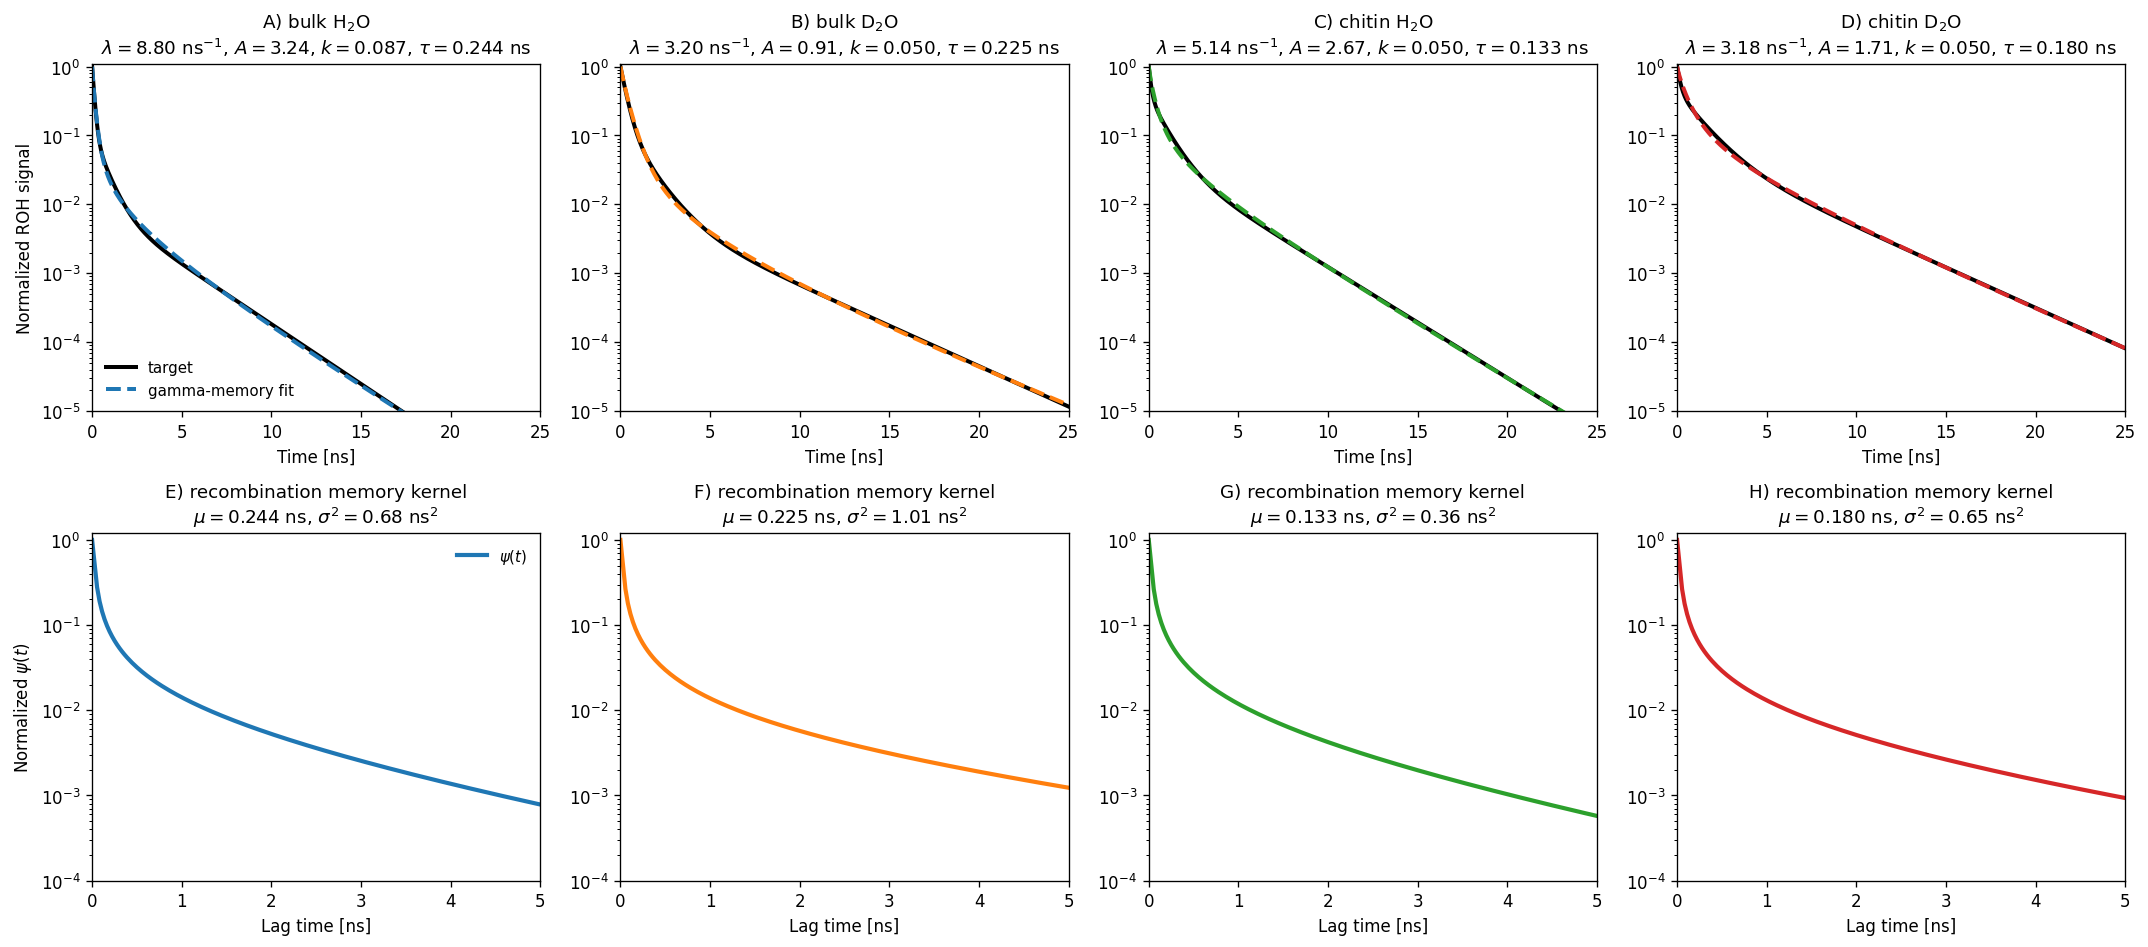

    condition  lambda_ns_inv       A       k  tau_ns  rel_err  rmse_log    cost
  bulk H$_2$O        8.80285 3.24373 0.08728 0.24429  0.02275   0.07529 2.62368
  bulk D$_2$O        3.20472 0.91498 0.05000 0.22496  0.03571   0.05944 1.74918
chitin H$_2$O        5.14034 2.66607 0.05000 0.13323  0.10632   0.05561 2.18093
chitin D$_2$O        3.17720 1.70612 0.05000 0.17976  0.11000   0.05295 1.98088


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PAPER FIGURE — HPTS gamma-memory reduced model
# No residuals, no Phi(t)
#
# Model:
#   dR/dt = -lambda R(t) + A int_0^t psi(t-s) R(s) ds
#
# Since there is no Q0 Phi(t) term in this model, we only plot psi(t).
# ============================================================

save_figure = True
figure_name = FIG_DIR / "figure4_hpts_gamma_memory_fits_kernels_no_phi.png"

plot_tmax_ns = fit_tmax_ns
kernel_tmax_ns = 5.0

condition_labels = {
    "bulk_H2O": r"bulk H$_2$O",
    "bulk_D2O": r"bulk D$_2$O",
    "chitin_H2O": r"chitin H$_2$O",
    "chitin_D2O": r"chitin D$_2$O",
}

panel_letters = list("ABCDEFGH")

if "fit_results" not in globals():
    raise RuntimeError("fit_results not found. Run the gamma-memory fitting block first.")

if "conditions_to_fit" not in globals():
    conditions_to_fit = list(fit_results.keys())

if "t" not in globals():
    if "t_ns" in globals():
        t = np.asarray(t_ns, dtype=float)
    else:
        raise RuntimeError("Neither t nor t_ns found.")

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 8.0),
    sharex=False
)

# ============================================================
# ROW 1 — TARGETS AND GAMMA FITS
# ============================================================

for j, name in enumerate(conditions_to_fit):
    ax = axes[0, j]

    res = fit_results[name]
    target = np.asarray(res["target"], dtype=float)
    R_fit = np.asarray(res["sim"]["R"], dtype=float)

    lam, A, k, tau = res["theta"]

    ax.semilogy(
        t, target,
        lw=2.4,
        color="black",
        label="target"
    )

    ax.semilogy(
        t, R_fit,
        "--",
        lw=2.4,
        color=colors[j % len(colors)],
        label="gamma-memory fit"
    )

    label = condition_labels.get(name, name.replace("_", " "))

    ax.set_title(
        rf"{panel_letters[j]}) {label}"
        "\n"
        rf"$\lambda={lam:.2f}$ ns$^{{-1}}$, "
        rf"$A={A:.2f}$, "
        rf"$k={k:.3f}$, "
        rf"$\tau={tau:.3f}$ ns",
        fontsize=11
    )

    ax.set_xlim(0, plot_tmax_ns)
    ax.set_ylim(1e-5, 1.1)
    ax.set_xlabel("Time [ns]")

    if j == 0:
        ax.set_ylabel(r"Normalized ROH signal")
        ax.legend(frameon=False, fontsize=9, loc="lower left")

    ax.grid(False)

# ============================================================
# ROW 2 — GAMMA MEMORY KERNELS ONLY
# ============================================================

for j, name in enumerate(conditions_to_fit):
    ax = axes[1, j]

    res = fit_results[name]
    sim = res["sim"]

    psi = np.asarray(sim["psi"], dtype=float)

    lam, A, k, tau = res["theta"]

    psi_norm = psi / np.max(psi)

    # Gamma kernel moments:
    # mean = tau, variance = tau^2/k
    mean_kernel = tau
    var_kernel = tau**2 / k

    ax.semilogy(
        t, psi_norm,
        lw=2.5,
        color=colors[j % len(colors)],
        label=r"$\psi(t)$"
    )

    ax.set_title(
        rf"{panel_letters[j+4]}) recombination memory kernel"
        "\n"
        rf"$\mu={mean_kernel:.3f}$ ns, "
        rf"$\sigma^2={var_kernel:.2f}$ ns$^2$",
        fontsize=11
    )

    ax.set_xlim(0, kernel_tmax_ns)
    ax.set_ylim(1e-4, 1.2)
    ax.set_xlabel("Lag time [ns]")

    if j == 0:
        ax.set_ylabel(r"Normalized $\psi(t)$")
        ax.legend(frameon=False, fontsize=9, loc="upper right")

    ax.grid(False)

plt.tight_layout()

if save_figure:
    plt.savefig(figure_name, dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / "figure4_hpts_gamma_memory_fits_kernels_no_phi.pdf", bbox_inches="tight")
    print(f"Figure saved as: {figure_name}")

plt.show()

# ============================================================
# Compact table for manuscript
# ============================================================

rows = []
for name in conditions_to_fit:
    res = fit_results[name]
    lam, A, k, tau = res["theta"]

    rows.append({
        "condition": condition_labels.get(name, name),
        "lambda_ns_inv": lam,
        "A": A,
        "k": k,
        "tau_ns": tau,
        "rel_err": res["rel_err"],
        "rmse_log": res["rmse_log"],
        "cost": res["cost"],
    })

df_hpts_gamma_summary = pd.DataFrame(rows)
print(df_hpts_gamma_summary.round(5).to_string(index=False))

## 9. Generated files

In [10]:
print("Generated figure files in figures/:")
for p in sorted(FIG_DIR.glob("figure*.*")):
    print(" -", p)

print("\nOther generated PNG/PDF files in current directory:")
for p in sorted(Path(".").glob("*.png")) + sorted(Path(".").glob("*.pdf")):
    print(" -", p)


Generated figure files in figures/:
 - figures/figure1_et_three_models_comparison.pdf
 - figures/figure1_et_three_models_comparison.png
 - figures/figure2_acid_70pct_kernel_comparison.pdf
 - figures/figure2_acid_70pct_kernel_comparison.png
 - figures/figure3_acid_base_global_three_kernel_fits.png
 - figures/figure4_hpts_gamma_memory_fits_kernels_no_phi.pdf
 - figures/figure4_hpts_gamma_memory_fits_kernels_no_phi.png

Other generated PNG/PDF files in current directory:
 - acid_base_three_kernel_fits.png
